# Retornos por descuento - notebook ordenado y auditado

Este notebook queda organizado en las seis secciones solicitadas. La bitácora de filtros permite revisar en qué paso se pierden filas, cuántas se pierden y qué porcentaje representa.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FECHA_FIN_DATOS_VENTAS = pd.Timestamp("2026-03-31")

# ============================================================
# Bitácora de filtros y transformaciones
# ============================================================
# Objetivo:
# - registrar cada filtro en el momento en que se aplica;
# - ver cuántas filas se pierden en cada paso;
# - evitar doble conteo: la bitácora secuencial cuenta pérdidas sobre la base
#   que sobrevivió al filtro anterior.

bitacora_filtros = []

def _n_unicos(df, id_col=None):
    if id_col is None or id_col not in df.columns:
        return np.nan
    return df[id_col].nunique(dropna=True)

def _normalizar_mask(mask, df):
    if isinstance(mask, (bool, np.bool_)):
        return pd.Series(bool(mask), index=df.index)

    if isinstance(mask, pd.Series):
        mask = mask.reindex(df.index)
    else:
        mask = pd.Series(mask, index=df.index)

    return mask.fillna(False).astype(bool)

def registrar_cambio(
    paso,
    df_antes,
    df_despues,
    grupo="",
    id_col=None,
    tipo="filtro",
    notas="",
):
    n_antes = len(df_antes)
    n_despues = len(df_despues)
    n_eliminadas = n_antes - n_despues
    pct_eliminado = n_eliminadas / n_antes if n_antes else 0

    registro = {
        "grupo": grupo,
        "tipo": tipo,
        "paso": paso,
        "filas_antes": n_antes,
        "filas_despues": n_despues,
        "filas_eliminadas": n_eliminadas,
        "pct_eliminado": pct_eliminado,
        "ids_antes": _n_unicos(df_antes, id_col),
        "ids_despues": _n_unicos(df_despues, id_col),
        "ids_eliminados": (
            _n_unicos(df_antes, id_col) - _n_unicos(df_despues, id_col)
            if id_col is not None and id_col in df_antes.columns and id_col in df_despues.columns
            else np.nan
        ),
        "notas": notas,
    }
    bitacora_filtros.append(registro)

    etiqueta_grupo = f"{grupo} | " if grupo else ""
    print(
        f"{etiqueta_grupo}{paso}: "
        f"{n_antes:,} -> {n_despues:,} filas "
        f"({n_eliminadas:,} eliminadas; {pct_eliminado:.1%})"
    )
    if notas:
        print(f"  Nota: {notas}")

    return registro

def registrar_estado(paso, df, grupo="", id_col=None, notas=""):
    return registrar_cambio(
        paso=paso,
        df_antes=df,
        df_despues=df,
        grupo=grupo,
        id_col=id_col,
        tipo="estado",
        notas=notas,
    )

def registrar_transformacion(paso, df_antes, df_despues, grupo="", id_col=None, notas=""):
    return registrar_cambio(
        paso=paso,
        df_antes=df_antes,
        df_despues=df_despues,
        grupo=grupo,
        id_col=id_col,
        tipo="transformación",
        notas=notas,
    )

def aplicar_filtro(df, condicion, paso, grupo="", id_col=None, notas=""):
    mask = condicion(df) if callable(condicion) else condicion
    mask = _normalizar_mask(mask, df)

    df_despues = df.loc[mask].copy()

    registrar_cambio(
        paso=paso,
        df_antes=df,
        df_despues=df_despues,
        grupo=grupo,
        id_col=id_col,
        tipo="filtro",
        notas=notas,
    )

    return df_despues

def _desempaquetar_filtro(filtro):
    if isinstance(filtro, dict):
        return (
            filtro["paso"],
            filtro["condicion"],
            filtro.get("notas", ""),
        )

    if len(filtro) == 2:
        paso, condicion = filtro
        notas = ""
    else:
        paso, condicion, notas = filtro

    return paso, condicion, notas

def auditar_filtros_secuenciales(df, filtros, grupo="", id_col=None):
    actual = df.copy()
    registros = []

    for filtro in filtros:
        paso, condicion, notas = _desempaquetar_filtro(filtro)
        actual = aplicar_filtro(
            actual,
            condicion,
            paso=paso,
            grupo=grupo,
            id_col=id_col,
            notas=notas,
        )
        registros.append(bitacora_filtros[-1])

    return actual, pd.DataFrame(registros)

def calcular_impacto_individual(df, filtros, id_col=None):
    filas = []

    for filtro in filtros:
        paso, condicion, notas = _desempaquetar_filtro(filtro)
        mask = condicion(df) if callable(condicion) else condicion
        mask = _normalizar_mask(mask, df)
        df_despues = df.loc[mask].copy()

        n_antes = len(df)
        n_despues = len(df_despues)

        filas.append({
            "paso": paso,
            "filas_antes": n_antes,
            "filas_despues": n_despues,
            "filas_eliminadas": n_antes - n_despues,
            "pct_eliminado": (n_antes - n_despues) / n_antes if n_antes else 0,
            "ids_antes": _n_unicos(df, id_col),
            "ids_despues": _n_unicos(df_despues, id_col),
            "ids_eliminados": (
                _n_unicos(df, id_col) - _n_unicos(df_despues, id_col)
                if id_col is not None and id_col in df.columns and id_col in df_despues.columns
                else np.nan
            ),
            "notas": notas,
        })

    return pd.DataFrame(filas)

def mostrar_bitacora_filtros(grupo=None):
    tabla = pd.DataFrame(bitacora_filtros)

    if tabla.empty:
        print("La bitácora de filtros todavía está vacía.")
        return tabla

    if grupo is not None:
        tabla = tabla.loc[tabla["grupo"].eq(grupo)].copy()

    if tabla.empty:
        print(f"No hay registros para el grupo: {grupo}")
        return tabla

    tabla = tabla.copy()
    tabla["pct_eliminado"] = (tabla["pct_eliminado"] * 100).round(2)

    columnas = [
        "grupo",
        "tipo",
        "paso",
        "filas_antes",
        "filas_despues",
        "filas_eliminadas",
        "pct_eliminado",
        "ids_antes",
        "ids_despues",
        "ids_eliminados",
        "notas",
    ]
    columnas = [col for col in columnas if col in tabla.columns]

    display(tabla[columnas])
    return tabla[columnas]


# 0. Cargas de datos

## 0.1 Ventas

In [34]:
# Cargar datos de ventas
path_ventas = "datos/Ventas por Cliente/ventas_con_descuento_aplicado.csv"
ventas = pd.read_csv(path_ventas)

registrar_estado(
    "Ventas cargadas",
    ventas,
    grupo="0. Cargas de datos",
)

print("Ventas - Filas:", ventas.shape[0])
display(ventas.head())


/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_986/2622178091.py:3: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


0. Cargas de datos | Ventas cargadas: 2,157,646 -> 2,157,646 filas (0 eliminadas; 0.0%)
Ventas - Filas: 2157646


,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
0,1227986,HR,37,SANTIAGO,SANTIAGO CENTRO COSTA,2026-02-16,3112,SALAME PIEZA 1KG LP,8274,1.0,...,8274.0,0.000000e+00,0.0,0.000000e+00,ninguno,NaN,False,False,8274.0,0.0
1,1176438,HR,37,NORTE 1,ANTOFAGASTA,2026-02-04,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",108216,27.0,...,7214.4,-1.110223e-14,0.0,-1.110223e-14,ninguno,NaN,False,False,108216.0,0.0
2,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-1.499879e+01,0.0,-1.499879e+01,ninguno,NaN,False,True,8274.0,1241.0
3,1011205,CB,32,SUR 1,RANCAGUA,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-1.499879e+01,0.0,-1.499879e+01,ninguno,NaN,False,True,8274.0,1241.0
4,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-09,8517,SALCHICHON CERVEZA MINI PZA 8x400 GR WI,22308,12.0,...,1486.8,-4.998655e+01,0.0,-4.998655e+01,liquidacion_forzado,NaN,False,True,44604.0,22296.0


In [35]:
ventas.columns

Index(['cod_cliente', 'cod_canal_comercial', 'cod_consolidado', 'zona',
       'distrito', 'fecha_factura', 'cod_sku', 'nombre_sku', 'monto_real',
       'kilo_real', 'precio_real', 'precio_lista', 'dscto_base',
       'dscto_volumen', 'dscto_binario', 'carta_impacto', 'id_descuento_base',
       'ids_descuento_volumen', 'id_descuento_binario',
       'id_descuento_carta_impacto', 'año_factura', 'mes_factura',
       'kg_por_unidad', 'peso_variable', 'cantidad_unidades',
       'cantidad_unidades_entera', 'inconsistencia', 'precio_por_unidad',
       'precio_lista_por_unidad', 'descuento_pct_observado',
       'descuento_pct_matcheado', 'diferencia_descuento_pct',
       'descuento_aplicado', 'id_descuento_aplicado', 'calza_con_descuento',
       'gap', 'monto_a_precio_lista', 'costo_descuento'],
      dtype='str')

## 0.2 Descuentos consolidados

In [36]:
path_descuentos = "datos/Descuentos históricos/consolidado_descuentos.csv"
descuentos = pd.read_csv(path_descuentos)

registrar_estado(
    "Descuentos cargados",
    descuentos,
    grupo="0. Cargas de datos",
    id_col="id_descuento" if "id_descuento" in descuentos.columns else None,
)

print("Descuentos - Filas:", descuentos.shape[0])
display(descuentos.head())


0. Cargas de datos | Descuentos cargados: 76,509 -> 76,509 filas (0 eliminadas; 0.0%)
Descuentos - Filas: 76509


,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
0,1,base,1006,CB,54.0,NaN,2026-03-02,2026-03-18,0.0,338
1,2,base,1006,CB,54.0,NaN,2026-03-19,9999-12-31,0.0,339
2,3,base,1006,HR,55.0,NaN,2026-03-02,2026-03-18,0.0,1118
3,4,base,1006,HR,55.0,NaN,2026-03-19,2026-03-29,0.0,1119
4,5,base,1006,HR,56.0,NaN,2023-11-01,2024-06-09,-24.8,1656


### Chequeos rápidos de descuentos crudos

In [37]:
descuentos[descuentos["cod_consolidado"].isna()]

,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
44,45,base,1020,CB,NaN,NaN,2024-02-05,2024-02-29,-10.0,3643
4898,4899,carta_impacto,1006,NaN,NaN,1002215.0,2026-04-01,2026-04-10,2878.0,3422
4899,4900,carta_impacto,1006,NaN,NaN,1002667.0,2026-04-06,2026-04-10,2878.0,3629
4900,4901,carta_impacto,1006,NaN,NaN,1008117.0,2026-04-07,2026-04-10,2878.0,3732
4901,4902,carta_impacto,1006,NaN,NaN,1039197.0,2026-04-06,2026-04-10,2878.0,3975
...,...,...,...,...,...,...,...,...,...,...
74335,74336,carta_impacto,970,NaN,NaN,92024.0,2026-04-01,2026-04-30,3746.0,20539
75634,75635,volumen,6770,CB,NaN,NaN,2024-04-15,2024-04-25,-21.2,2179
75696,75697,volumen,6771,CB,NaN,NaN,2024-04-15,2024-04-25,-26.8,2180
75843,75844,volumen,689,CB,NaN,NaN,2024-05-12,2024-05-25,-20.0,2178


In [38]:
descuentos[descuentos["tipo_descuento"]=="base"]["monto_descuento"].describe()

count    3588.000000
mean      -12.648690
std        13.395793
min       -57.100000
25%       -20.000000
50%        -6.000000
75%        -3.000000
max         0.000000
Name: monto_descuento, dtype: float64

In [39]:
descuentos[
    (descuentos["tipo_descuento"]=="binario") &
    (descuentos["monto_descuento"] < -30)
]

,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
4253,4254,binario,3951,CB,32.0,NaN,2025-07-08,2025-07-28,-40.0,255
4254,4255,binario,3951,CB,32.0,NaN,2025-07-29,2025-08-16,-50.0,256
4258,4259,binario,3951,CB,54.0,NaN,2025-07-08,2025-07-28,-40.0,634
4259,4260,binario,3951,CB,54.0,NaN,2025-07-29,2025-08-16,-50.0,635
4263,4264,binario,3951,HR,37.0,NaN,2025-07-08,2025-07-28,-40.0,791
4264,4265,binario,3951,HR,37.0,NaN,2025-07-29,2025-08-16,-50.0,792
4268,4269,binario,3951,HR,55.0,NaN,2025-07-08,2025-07-28,-40.0,849
4269,4270,binario,3951,HR,55.0,NaN,2025-07-29,2025-08-16,-50.0,850
4495,4496,binario,6775,CB,32.0,NaN,2025-07-08,2025-07-14,-35.0,314
4497,4498,binario,6775,CB,32.0,NaN,2025-12-26,2026-01-13,-35.0,316


## 0.3 Costos por SKU

In [40]:
# Un Excel con varias hojas, una por mes, mismas columnas en todas las hojas.
# Se concatenan todas las hojas en un solo DataFrame con una columna adicional que indica el mes.
path_costos = "datos/Consolidado ABC SKU (oct25'-mar26') FINAL.xlsx"
lista_dfs_costos = []
xls = pd.ExcelFile(path_costos, engine="openpyxl")

for sheet_name in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet_name, engine="openpyxl")
    df["Mes"] = sheet_name
    lista_dfs_costos.append(df)

costos = pd.concat(lista_dfs_costos, ignore_index=True)

registrar_estado(
    "Costos cargados",
    costos,
    grupo="0. Cargas de datos",
)

print("Costos - Filas:", costos.shape[0])
display(costos.head())


0. Cargas de datos | Costos cargados: 1,362 -> 1,362 filas (0 eliminadas; 0.0%)
Costos - Filas: 1362


,SKU,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,...,Energía por kilo,Distribución Fijo por kilo,T Producción por kilo,Gastos DM Canales por kilo,Gastos DM Marketing por kilo,Reponer por kilo,Gastos. Zonales Directos por kilo,O. G. Fijos Indirectos por kilo,Otros Distribución Variable por kilo,Mes
0,20,58043.950,286856695,26338148.0,1.013134e+08,9.314235e+05,6.362547e+06,2.974402e+06,3.115924e+07,9.093773e+05,...,109.616023,51.243956,536.821480,15.667047,69.781019,107.213380,165.224788,356.538820,11.496824,Mar 26
1,27,3350.615,16824295,968263.0,5.162494e+06,5.376687e+04,3.672811e+05,1.716988e+05,2.182250e+06,3.914600e+04,...,109.616023,51.243956,651.298434,11.683227,70.917961,46.616111,174.134955,361.737830,1.065923,Mar 26
2,30,28289.940,139253232,10049703.0,6.186897e+07,4.539649e+05,3.201319e+06,1.449688e+06,1.750704e+07,2.934156e+05,...,113.161033,51.243956,618.843430,10.371729,69.481203,84.973946,173.792703,355.245462,7.533394,Mar 26
3,102,13133.700,74013452,5222723.0,2.788324e+07,2.107547e+05,1.313908e+06,6.730227e+05,3.367262e+06,2.479957e+05,...,100.040929,51.243956,256.383338,18.882393,79.456343,78.698590,153.891363,402.053980,30.895221,Mar 26
4,210,178055.860,617396049,48810519.0,1.852048e+08,3.635689e+06,1.116290e+07,9.124287e+06,9.683573e+07,1.623069e+06,...,62.693270,51.243956,543.850298,9.115506,48.949864,76.885585,100.209147,259.732670,11.442677,Mar 26


In [41]:
costos.columns

Index(['SKU', ' Kilos Finales', 'Facturación', 'Aporte', 'Costo',
       'Frío Externo', 'Energía', 'Distribución Fijo', 'T Producción',
       'Gastos DM Canales', 'Gastos DM Marketing', 'Reponer',
       'Gastos. Zonales Directos', 'O. G. Fijos Indirectos',
       'Otros Distribución Variable', 'Aporte por kilo', 'Costo por kilo',
       'Frío Externo por kilo', 'Energía por kilo',
       'Distribución Fijo por kilo', 'T Producción por kilo',
       'Gastos DM Canales por kilo', 'Gastos DM Marketing por kilo',
       'Reponer por kilo', 'Gastos. Zonales Directos por kilo',
       'O. G. Fijos Indirectos por kilo',
       'Otros Distribución Variable por kilo', 'Mes'],
      dtype='str')

In [42]:
cols_costos = [
    "Mes",
    "SKU",
    " Kilos Finales",
    "Facturación",
    "Aporte",
    "Costo",
    "Frío Externo",
    "Energía",
    "Distribución Fijo",
    "T Producción",
    "Gastos DM Canales",
    "Gastos DM Marketing",
    "Reponer",
    "Gastos. Zonales Directos",
    "O. G. Fijos Indirectos",
    "Otros Distribución Variable",
]

costos_antes_columnas = costos.copy()
costos = costos[cols_costos].copy()

registrar_transformacion(
    "Costos: selección de columnas útiles",
    costos_antes_columnas,
    costos,
    grupo="0. Cargas de datos",
    notas=f"Columnas seleccionadas: {len(cols_costos)}",
)

display(costos.head())


0. Cargas de datos | Costos: selección de columnas útiles: 1,362 -> 1,362 filas (0 eliminadas; 0.0%)
  Nota: Columnas seleccionadas: 16


,Mes,SKU,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable
0,Mar 26,20,58043.950,286856695,26338148.0,1.013134e+08,9.314235e+05,6.362547e+06,2.974402e+06,3.115924e+07,9.093773e+05,4.050366e+06,6.223088e+06,9.590299e+06,2.069492e+07,6.673211e+05
1,Mar 26,27,3350.615,16824295,968263.0,5.162494e+06,5.376687e+04,3.672811e+05,1.716988e+05,2.182250e+06,3.914600e+04,2.376188e+05,1.561926e+05,5.834592e+05,1.212044e+06,3.571497e+03
2,Mar 26,30,28289.940,139253232,10049703.0,6.186897e+07,4.539649e+05,3.201319e+06,1.449688e+06,1.750704e+07,2.934156e+05,1.965619e+06,2.403908e+06,4.916585e+06,1.004987e+07,2.131193e+05
3,Mar 26,102,13133.700,74013452,5222723.0,2.788324e+07,2.107547e+05,1.313908e+06,6.730227e+05,3.367262e+06,2.479957e+05,1.043556e+06,1.033604e+06,2.021163e+06,5.280456e+06,4.057686e+05
4,Mar 26,210,178055.860,617396049,48810519.0,1.852048e+08,3.635689e+06,1.116290e+07,9.124287e+06,9.683573e+07,1.623069e+06,8.715810e+06,1.368993e+07,1.784283e+07,4.624692e+07,2.037436e+06


In [43]:
costos_totales = costos.groupby(["SKU"]).sum().reset_index()
costos_totales.head()

,SKU,Mes,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable
0,20,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,335586.218,1662597580,153623897.0,6.106304e+08,7.001417e+06,4.006351e+07,1.867814e+07,1.710162e+08,6.286412e+06,2.557901e+07,3.301842e+07,5.643622e+07,1.059107e+08,3.132913e+06
1,27,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,19992.314,96892820,5081558.0,3.159423e+07,4.193767e+05,2.394141e+06,1.112293e+06,1.034808e+07,1.377657e+05,1.474946e+06,8.965587e+05,3.313494e+06,6.182961e+06,3.760482e+04
2,30,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,166105.952,823931212,66366773.0,3.727935e+08,3.463517e+06,2.051210e+07,9.254694e+06,9.408060e+07,3.468700e+06,1.265933e+07,1.274087e+07,3.103956e+07,5.252660e+07,1.192458e+06
3,102,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,76809.925,431581113,33333712.0,1.736206e+08,1.609275e+06,8.061725e+06,4.282384e+06,1.821598e+07,2.161787e+06,6.481077e+06,5.942076e+06,1.108287e+07,2.718273e+07,4.919939e+06
4,151,Dic 25Nov 25Oct 25,4611.500,16473437,110102.0,6.366029e+06,5.175683e+04,2.510712e+05,2.476763e+05,2.694126e+06,2.367651e+04,1.942270e+05,4.545280e+04,4.993600e+05,1.016952e+06,1.800514e+04


In [44]:
costos_totales["Margen Producción"] = (
    costos_totales["Facturación"]
    - costos_totales["Costo"]
    - costos_totales["Distribución Fijo"]
    - costos_totales["Frío Externo"]
)

In [45]:
costos_totales["Margen por Kilo"] = costos_totales["Margen Producción"] / costos_totales[" Kilos Finales"]

## 0.4 Datos SKU

In [46]:
path_info_sku = "datos/Subfamilia y subcategoría.xlsx"
info_sku = pd.read_excel(path_info_sku)

registrar_estado(
    "Info SKU cargada",
    info_sku,
    grupo="0. Cargas de datos",
    id_col="sku" if "sku" in info_sku.columns else None,
)

display(info_sku.head())


0. Cargas de datos | Info SKU cargada: 1,873 -> 1,873 filas (0 eliminadas; 0.0%)


,sku,Subfamilia,Subcategora,Texto breve de material,Grupo art.,Creado el,estado,Válido de,GTPos,Denominación,...,Denominación.2,Tip Carne,Denom..1,Gr. Empaq.,envasado_granel,Gr. Carga,Denominación.3,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,Arrollado,Arrollado Lomo c/Ají,ARROLLADO LOMO CON AJI SJ,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,NaN,NaN,ARROLLADO LOMO CORTADO SJ,SJ,20.10.2005,Bloqueado,19.10.2020,NORM,Posición normal,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,NaN,NaN,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,SJ,27.01.2011,Bloqueado,08.04.2016,NORM,Posición normal,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,NaN,NaN,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,SJ,23.05.2013,Bloqueado,18.03.2020,NORM,Posición normal,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,Arrollado,Arrollado Lomo,ARROLLADO LOMO SIN AJI SJ,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [47]:
info_sku.columns
# Index(['sku', 'Subfamilia', 'Subcategora', 'Texto breve de material',
#        'Grupo art.', 'Creado el', 'estado', 'Válido de', 'GTPos',
#        'Denominación', 'Bruto', 'kg Neto', 'Un', 'Volumen', 'UV', 'Longitud',
#        'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
#        'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
#        'Denominación.1', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.2',
#        'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'envasado_granel', 'Gr. Carga',
#        'Denominación.3', 'Conservación', 'Jerarquía Clte.(Familia DP)',
#        'Descripción'],
#       dtype='str')

Index(['sku', 'Subfamilia', 'Subcategora', 'Texto breve de material',
       'Grupo art.', 'Creado el', 'estado', 'Válido de', 'GTPos',
       'Denominación', 'Bruto', 'kg Neto', 'Un', 'Volumen', 'UV', 'Longitud',
       'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
       'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
       'Denominación.1', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.2',
       'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'envasado_granel', 'Gr. Carga',
       'Denominación.3', 'Conservación', 'Jerarquía Clte.(Familia DP)',
       'Descripción'],
      dtype='str')

In [48]:
path_seg_productos = "datos/Segmentacion_productos (1).xlsx"
seg_productos = pd.read_excel(path_seg_productos)

registrar_estado(
    "Segmentación productos cargada",
    seg_productos,
    grupo="0. Cargas de datos",
    id_col="sku" if "sku" in seg_productos.columns else None,
)

display(seg_productos.head())


0. Cargas de datos | Segmentación productos cargada: 218 -> 218 filas (0 eliminadas; 0.0%)


,sku,familia_hana,marca,descripción,kilos,ingresos_m,margen_1_m,margen_2_m,ebitda_m,marca_normalizada,ebitda_pct,margen_pct,segmento_producto,Infaltables
0,3109,JAMON G2,LA PREFERIDA,JAMON SANDWICH LP,398390.580,2075342.036,1.320033e+06,758334.664456,623179.820711,la preferida,0.300278,0.636056,Héroe,Faltable
1,421,PATE,SAN JORGE,PATE TERNERA 8x125 GRS.SJ,508267.552,1954343.478,1.329923e+06,478819.218456,348340.995060,san jorge,0.178239,0.680496,Héroe,Faltable
2,970,CARNES,SAN JORGE,MOLIDA 14x250 GR SJ,411706.750,1811076.827,9.322576e+05,435391.298100,316841.069705,san jorge,0.174946,0.514753,Héroe,Faltable
3,6783,LACTEOS,Los Nogales,MANTEQUILLA 125 GRS x8 LOS NOGALES,179480.900,1732725.366,5.869634e+05,335079.432902,229628.847484,los nogales,0.132525,0.338752,Héroe,Faltable
4,210,FIAMBRES,SAN JORGE,FIAMBRE SANDWICH SJ,809267.352,2903166.617,2.010887e+06,960805.242614,766732.128914,san jorge,0.264102,0.692653,Héroe,210


In [49]:
seg_productos.columns
# Index(['sku', 'familia_hana', 'marca', 'descripción', 'kilos', 'ingresos_m',
#        'margen_1_m', 'margen_2_m', 'ebitda_m', 'marca_normalizada',
#        'ebitda_pct', 'margen_pct', 'segmento_producto', 'Infaltables'],
#       dtype='str')

Index(['sku', 'familia_hana', 'marca', 'descripción', 'kilos', 'ingresos_m',
       'margen_1_m', 'margen_2_m', 'ebitda_m', 'marca_normalizada',
       'ebitda_pct', 'margen_pct', 'segmento_producto', 'Infaltables'],
      dtype='str')

# 1. Cruces y filtros pre-análisis

## 1.1 Filtros de ventas auditados

In [50]:
# Filtrar solo los canales relevantes.
# La bitácora registra cuántas filas se pierden en cada paso.
canales_relevantes = [
    32,  # COBERTURA
    54,  # VOLUMEN COBERTURA
    # 67,  # MAYORISTAS CADENAS
    # 57,  # MAYORISTA B VOLUMEN
    # 38,  # OTROS MAYORISTAS
    # 55,  # HORECA VOLUMEN
    # 37,  # OTROS HORECA
]

ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"])

ventas = aplicar_filtro(
    ventas,
    ventas["cod_consolidado"].isin(canales_relevantes),
    paso="Ventas: cod_consolidado en canales relevantes",
    grupo="1. Cruces y filtros pre-análisis",
    notas=f"Canales incluidos: {canales_relevantes}",
)

ventas = aplicar_filtro(
    ventas,
    ventas["fecha_factura"] <= FECHA_FIN_DATOS_VENTAS,
    paso="Ventas: fecha_factura <= fecha de corte",
    grupo="1. Cruces y filtros pre-análisis",
    notas=f"Fecha de corte: {FECHA_FIN_DATOS_VENTAS:%Y-%m-%d}",
)

assert ventas["fecha_factura"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay ventas posteriores a la fecha máxima del análisis."
)

print("Fecha máxima de ventas usada:", ventas["fecha_factura"].max().strftime("%Y-%m-%d"))
display(ventas.head())


1. Cruces y filtros pre-análisis | Ventas: cod_consolidado en canales relevantes: 2,157,646 -> 1,957,253 filas (200,393 eliminadas; 9.3%)
  Nota: Canales incluidos: [32, 54]
1. Cruces y filtros pre-análisis | Ventas: fecha_factura <= fecha de corte: 1,957,253 -> 1,820,155 filas (137,098 eliminadas; 7.0%)
  Nota: Fecha de corte: 2026-03-31
Fecha máxima de ventas usada: 2026-03-31


,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
2,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-14.998792,0.0,-14.998792,ninguno,NaN,False,True,8274.0,1241.0
3,1011205,CB,32,SUR 1,RANCAGUA,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-14.998792,0.0,-14.998792,ninguno,NaN,False,True,8274.0,1241.0
4,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-09,8517,SALCHICHON CERVEZA MINI PZA 8x400 GR WI,22308,12.0,...,1486.8,-49.986546,0.0,-49.986546,liquidacion_forzado,NaN,False,True,44604.0,22296.0
5,1123804,CB,32,NORTE 1,ANTOFAGASTA,2026-02-03,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",14429,3.6,...,7214.4,0.001386,0.0,0.001386,ninguno,NaN,False,False,14428.8,-0.2
6,1067823,CB,54,NORTE 1,ANTOFAGASTA,2026-02-03,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",18396,5.4,...,7214.4,-15.003326,-15.0,-0.003326,binario,4837.0,True,False,21643.2,3247.2


## 1.2 Filtros de descuentos auditados

In [52]:
# Normalizar nombre y formato del tipo de descuento.
# Nota: en algunos archivos puede aparecer escrito como "tipo_desuento".
if "tipo_descuento" not in descuentos.columns and "tipo_desuento" in descuentos.columns:
    descuentos = descuentos.rename(columns={"tipo_desuento": "tipo_descuento"})

descuentos["tipo_descuento"] = (
    descuentos["tipo_descuento"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Filtros secuenciales pre-análisis.
# Cada paso se registra en la bitácora, por lo que las filas eliminadas no se doble cuentan.
descuentos = aplicar_filtro(
    descuentos,
    descuentos["monto_descuento"] < 0,
    paso="Descuentos: monto_descuento < 0",
    grupo="1. Cruces y filtros pre-análisis",
    id_col="id_descuento",
    notas="Excluye descuentos nulos, cero o positivos.",
)

descuentos = aplicar_filtro(
    descuentos,
    descuentos["tipo_descuento"].fillna("") != "carta_impacto",
    paso="Descuentos: excluir carta_impacto",
    grupo="1. Cruces y filtros pre-análisis",
    id_col="id_descuento",
)

cod_consolidado_ventas = ventas["cod_consolidado"].dropna().unique()

descuentos = aplicar_filtro(
    descuentos,
    ((descuentos["cod_consolidado"].isin(cod_consolidado_ventas)) | (descuentos["cod_consolidado"].isna())),
    paso="Descuentos: cod_consolidado presente en ventas filtradas",
    grupo="1. Cruces y filtros pre-análisis",
    id_col="id_descuento",
    notas=f"Consolidados disponibles en ventas: {len(cod_consolidado_ventas)}",
)

# Normalización de fechas y ajuste de descuentos abiertos al corte de ventas.
descuentos["fecha_fin_original"] = descuentos["fecha_fin"].astype("string").str.strip()

fecha_fin_normalizada = descuentos["fecha_fin_original"].replace(
    {"9999-12-31": FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")}
)

descuentos["fecha_inicio"] = pd.to_datetime(descuentos["fecha_inicio"])
descuentos["fecha_fin"] = pd.to_datetime(fecha_fin_normalizada)

descuentos = aplicar_filtro(
    descuentos,
    descuentos["fecha_inicio"].dt.year >= 2025,
    paso="Descuentos: fecha_inicio desde 2025",
    grupo="1. Cruces y filtros pre-análisis",
    id_col="id_descuento",
)

n_fecha_fin_abierta = descuentos["fecha_fin_original"].eq("9999-12-31").sum()

mask_inicio_post_corte = descuentos["fecha_inicio"] > FECHA_FIN_DATOS_VENTAS
n_excluidos_inicio_post_corte = mask_inicio_post_corte.sum()

mask_fecha_fin_post_corte = descuentos["fecha_fin"] > FECHA_FIN_DATOS_VENTAS
n_finitos_recortados_post_corte = (
    mask_fecha_fin_post_corte
    & ~descuentos["fecha_fin_original"].eq("9999-12-31")
).sum()

descuentos_antes_recorte_fecha = descuentos.copy()

descuentos.loc[mask_fecha_fin_post_corte, "fecha_fin"] = FECHA_FIN_DATOS_VENTAS

registrar_transformacion(
    "Descuentos: recortar fecha_fin posterior al corte",
    descuentos_antes_recorte_fecha,
    descuentos,
    grupo="1. Cruces y filtros pre-análisis",
    id_col="id_descuento",
    notas=(
        f"fecha_fin_original == 9999-12-31: {n_fecha_fin_abierta}; "
        f"finitos recortados por exceder corte: {n_finitos_recortados_post_corte}"
    ),
)

descuentos = aplicar_filtro(
    descuentos,
    ~mask_inicio_post_corte,
    paso="Descuentos: fecha_inicio <= fecha de corte",
    grupo="1. Cruces y filtros pre-análisis",
    id_col="id_descuento",
    notas=f"Excluidos por empezar después del corte: {n_excluidos_inicio_post_corte}",
)

mask_periodo_invalido = descuentos["fecha_fin"] < descuentos["fecha_inicio"]
n_excluidos_periodo_invalido = mask_periodo_invalido.sum()

descuentos = aplicar_filtro(
    descuentos,
    ~mask_periodo_invalido,
    paso="Descuentos: fecha_fin >= fecha_inicio",
    grupo="1. Cruces y filtros pre-análisis",
    id_col="id_descuento",
    notas=f"Excluidos por periodo inválido tras el corte: {n_excluidos_periodo_invalido}",
)

assert descuentos["fecha_fin"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay descuentos con fecha_fin posterior a la fecha máxima del análisis."
)
assert (descuentos["fecha_fin"] >= descuentos["fecha_inicio"]).all(), (
    "Hay descuentos con fecha_fin anterior a fecha_inicio."
)

print("Descuentos después de filtros pre-análisis - Filas:", descuentos.shape[0])
mostrar_bitacora_filtros("1. Cruces y filtros pre-análisis")


1. Cruces y filtros pre-análisis | Descuentos: monto_descuento < 0: 6,660 -> 6,660 filas (0 eliminadas; 0.0%)
  Nota: Excluye descuentos nulos, cero o positivos.
1. Cruces y filtros pre-análisis | Descuentos: excluir carta_impacto: 6,660 -> 6,660 filas (0 eliminadas; 0.0%)
1. Cruces y filtros pre-análisis | Descuentos: cod_consolidado presente en ventas filtradas: 6,660 -> 2,749 filas (3,911 eliminadas; 58.7%)
  Nota: Consolidados disponibles en ventas: 2
1. Cruces y filtros pre-análisis | Descuentos: fecha_inicio desde 2025: 2,749 -> 2,008 filas (741 eliminadas; 27.0%)
1. Cruces y filtros pre-análisis | Descuentos: recortar fecha_fin posterior al corte: 2,008 -> 2,008 filas (0 eliminadas; 0.0%)
  Nota: fecha_fin_original == 9999-12-31: 585; finitos recortados por exceder corte: 80
1. Cruces y filtros pre-análisis | Descuentos: fecha_inicio <= fecha de corte: 2,008 -> 1,958 filas (50 eliminadas; 2.5%)
  Nota: Excluidos por empezar después del corte: 50
1. Cruces y filtros pre-análisis 

,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
6,1. Cruces y filtros pre-análisis,filtro,Ventas: cod_consolidado en canales relevantes,2157646,1957253,200393,9.29,NaN,NaN,NaN,"Canales incluidos: [32, 54]"
7,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura <= fecha de corte,1957253,1820155,137098,7.00,NaN,NaN,NaN,Fecha de corte: 2026-03-31
8,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,76509,6660,69849,91.30,76509.0,6660.0,69849.0,"Excluye descuentos nulos, cero o positivos."
9,1. Cruces y filtros pre-análisis,filtro,Descuentos: excluir carta_impacto,6660,6660,0,0.00,6660.0,6660.0,0.0,
10,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,6660,6660,0,0.00,6660.0,6660.0,0.0,"Excluye descuentos nulos, cero o positivos."
11,1. Cruces y filtros pre-análisis,filtro,Descuentos: excluir carta_impacto,6660,6660,0,0.00,6660.0,6660.0,0.0,
12,1. Cruces y filtros pre-análisis,filtro,Descuentos: cod_consolidado presente en ventas...,6660,2749,3911,58.72,6660.0,2749.0,3911.0,Consolidados disponibles en ventas: 2
13,1. Cruces y filtros pre-análisis,filtro,Descuentos: fecha_inicio desde 2025,2749,2008,741,26.96,2749.0,2008.0,741.0,
14,1. Cruces y filtros pre-análisis,transformación,Descuentos: recortar fecha_fin posterior al corte,2008,2008,0,0.00,2008.0,2008.0,0.0,fecha_fin_original == 9999-12-31: 585; finitos...
15,1. Cruces y filtros pre-análisis,filtro,Descuentos: fecha_inicio <= fecha de corte,2008,1958,50,2.49,2008.0,1958.0,50.0,Excluidos por empezar después del corte: 50


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
6,1. Cruces y filtros pre-análisis,filtro,Ventas: cod_consolidado en canales relevantes,2157646,1957253,200393,9.29,NaN,NaN,NaN,"Canales incluidos: [32, 54]"
7,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura <= fecha de corte,1957253,1820155,137098,7.00,NaN,NaN,NaN,Fecha de corte: 2026-03-31
8,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,76509,6660,69849,91.30,76509.0,6660.0,69849.0,"Excluye descuentos nulos, cero o positivos."
9,1. Cruces y filtros pre-análisis,filtro,Descuentos: excluir carta_impacto,6660,6660,0,0.00,6660.0,6660.0,0.0,
10,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,6660,6660,0,0.00,6660.0,6660.0,0.0,"Excluye descuentos nulos, cero o positivos."
11,1. Cruces y filtros pre-análisis,filtro,Descuentos: excluir carta_impacto,6660,6660,0,0.00,6660.0,6660.0,0.0,
12,1. Cruces y filtros pre-análisis,filtro,Descuentos: cod_consolidado presente en ventas...,6660,2749,3911,58.72,6660.0,2749.0,3911.0,Consolidados disponibles en ventas: 2
13,1. Cruces y filtros pre-análisis,filtro,Descuentos: fecha_inicio desde 2025,2749,2008,741,26.96,2749.0,2008.0,741.0,
14,1. Cruces y filtros pre-análisis,transformación,Descuentos: recortar fecha_fin posterior al corte,2008,2008,0,0.00,2008.0,2008.0,0.0,fecha_fin_original == 9999-12-31: 585; finitos...
15,1. Cruces y filtros pre-análisis,filtro,Descuentos: fecha_inicio <= fecha de corte,2008,1958,50,2.49,2008.0,1958.0,50.0,Excluidos por empezar después del corte: 50


## 1.3 Funciones y cruces de clasificación SKU

In [53]:
COLUMNAS_CLASIFICACION_SKU = [
    "subfamilia",
    "familia_hana",
    "segmento_producto",
]

ETIQUETAS_FALTANTES_CLASIFICACION_SKU = {
    "subfamilia": "Sin subfamilia",
    "familia_hana": "Sin familia_hana",
    "segmento_producto": "Sin segmento_producto",
}


def _normalizar_texto_categoria(serie, valor_default):
    serie = pd.Series(serie, copy=False).astype("string").str.strip()
    return serie.fillna("").replace("", valor_default)


def enriquecer_resultados_con_clasificacion_sku(
    resultados_df,
    info_sku_base=None,
    seg_productos_base=None,
):
    if "cod_sku" not in resultados_df.columns:
        raise KeyError("resultados_df debe contener la columna 'cod_sku'.")

    resultados = resultados_df.copy()
    n_filas_original = len(resultados)
    n_ids_original = (
        resultados[ID_COL_ANALISIS].nunique()
        if ID_COL_ANALISIS in resultados.columns
        else None
    )

    resultados = resultados.drop(columns=COLUMNAS_CLASIFICACION_SKU, errors="ignore")
    resultados["__cod_sku_merge"] = pd.to_numeric(resultados["cod_sku"], errors="coerce")

    info_sku_base = info_sku if info_sku_base is None else info_sku_base
    seg_productos_base = seg_productos if seg_productos_base is None else seg_productos_base

    info_sku_merge = (
        info_sku_base[["sku", "Subfamilia"]]
        .copy()
        .assign(__cod_sku_merge=lambda df: pd.to_numeric(df["sku"], errors="coerce"))
        .dropna(subset=["__cod_sku_merge"])
        .drop_duplicates(subset=["__cod_sku_merge"], keep="first")
        .drop(columns=["sku"])
        .rename(columns={"Subfamilia": "subfamilia"})
    )

    seg_productos_merge = (
        seg_productos_base[["sku", "familia_hana", "segmento_producto"]]
        .copy()
        .assign(__cod_sku_merge=lambda df: pd.to_numeric(df["sku"], errors="coerce"))
        .dropna(subset=["__cod_sku_merge"])
        .drop_duplicates(subset=["__cod_sku_merge"], keep="first")
        .drop(columns=["sku"])
    )

    resultados = resultados.merge(info_sku_merge, on="__cod_sku_merge", how="left")
    resultados = resultados.merge(seg_productos_merge, on="__cod_sku_merge", how="left")

    for columna, etiqueta_faltante in ETIQUETAS_FALTANTES_CLASIFICACION_SKU.items():
        resultados[columna] = _normalizar_texto_categoria(
            resultados[columna],
            etiqueta_faltante,
        )

    resultados = resultados.drop(columns=["__cod_sku_merge"])

    columnas_clasificacion = [
        columna for columna in COLUMNAS_CLASIFICACION_SKU
        if columna in resultados.columns
    ]
    columnas_restantes = [
        columna for columna in resultados.columns
        if columna not in columnas_clasificacion
    ]

    if "cod_sku" in columnas_restantes:
        posicion_cod_sku = columnas_restantes.index("cod_sku") + 1
        columnas_ordenadas = (
            columnas_restantes[:posicion_cod_sku]
            + columnas_clasificacion
            + columnas_restantes[posicion_cod_sku:]
        )
        resultados = resultados[columnas_ordenadas]

    assert len(resultados) == n_filas_original, (
        "El merge de clasificación SKU cambió la cantidad de filas de resultados_df."
    )

    if n_ids_original is not None:
        assert resultados[ID_COL_ANALISIS].nunique() == n_ids_original, (
            "El merge de clasificación SKU cambió la cantidad de ids únicos en resultados_df."
        )

    return resultados

## 1.4 Unidad de análisis: agrupación de descuentos

In [54]:
# Unidad correcta de análisis:
# no cambiamos el id_descuento original, sino que creamos un id_descuento_analisis.
# Dos registros pertenecen al mismo descuento si coinciden en:
# cod_sku, tipo_descuento, cod_canal, cod_consolidado, fecha_inicio y fecha_fin.
ID_COL_ANALISIS = "id_descuento_analisis"

COLUMNAS_LLAVE_DESCUENTO_ANALISIS = [
    "cod_sku",
    "tipo_descuento",
    "cod_canal",
    "cod_consolidado",
    "fecha_inicio",
    "fecha_fin",
]

def _ids_ordenados(serie):
    valores = pd.Series(serie.dropna().unique())
    valores_num = pd.to_numeric(valores, errors="coerce")
    if len(valores) > 0 and valores_num.notna().all():
        return sorted(valores_num.astype(int).tolist())
    return sorted(valores.astype(str).tolist())

def filtrar_ventas_por_llave(ventas_df, sku, canal, consolidado):
    filtro = (
        (ventas_df["cod_sku"] == sku)
        & (ventas_df["cod_canal_comercial"] == canal)
    )

    if pd.notna(consolidado) and str(consolidado).strip() != "":
        filtro = filtro & (ventas_df["cod_consolidado"] == consolidado)

    return ventas_df[filtro].copy()

def filtrar_ventas_por_ids_descuento(ventas_df, ids_descuento):
    ids_originales = pd.Series(ids_descuento)

    ids_num = pd.to_numeric(ids_originales, errors="coerce").dropna().unique()
    if len(ids_num) > 0:
        id_aplicado_num = pd.to_numeric(
            ventas_df["id_descuento_aplicado"],
            errors="coerce"
        )
        return ventas_df[id_aplicado_num.isin(ids_num)].copy()

    ids_str = ids_originales.dropna().astype(str).unique().tolist()
    return ventas_df[
        ventas_df["id_descuento_aplicado"].astype("string").isin(ids_str)
    ].copy()


TIPOS_DESCUENTO_ACTIVACION_PARCIAL = {"binario", "volumen"}

def _normalizar_tipo_descuento_activacion(valor):
    if pd.isna(valor):
        return ""

    valor = str(valor).strip().lower()

    if valor.startswith("binario"):
        return "binario"
    if valor.startswith("volumen"):
        return "volumen"

    return valor

def filtrar_ventas_periodo_descuento(
    ventas_df,
    ids_descuento,
    fecha_inicio,
    fecha_fin,
    tipo_descuento,
):
    """
    Filtra las ventas usadas para medir la demanda durante el periodo de descuento.

    Para descuentos de activación parcial (binario y volumen), la demanda del periodo
    debe considerar tanto las ventas con el descuento correspondiente como las ventas
    del mismo periodo y llave sin ningún descuento.

    Para el resto de los tipos de descuento se mantiene la lógica original: sólo ventas
    asociadas a los ids del descuento.
    """
    fecha_inicio = pd.to_datetime(fecha_inicio).normalize()
    fecha_fin = pd.to_datetime(fecha_fin).normalize()

    fechas_factura = pd.to_datetime(ventas_df["fecha_factura"]).dt.normalize()
    ventas_periodo = ventas_df[
        (fechas_factura >= fecha_inicio)
        & (fechas_factura <= fecha_fin)
    ].copy()

    ventas_descuento = filtrar_ventas_por_ids_descuento(
        ventas_periodo,
        ids_descuento,
    )

    tipo_norm = _normalizar_tipo_descuento_activacion(tipo_descuento)

    if tipo_norm not in TIPOS_DESCUENTO_ACTIVACION_PARCIAL:
        return ventas_descuento

    ventas_sin_descuento_periodo = ventas_periodo[
        ventas_periodo["descuento_aplicado"]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("ninguno")
    ].copy()

    return (
        pd.concat(
            [ventas_descuento, ventas_sin_descuento_periodo],
            axis=0,
        )
        .loc[lambda df: ~df.index.duplicated(keep="first")]
        .copy()
    )

descuentos = descuentos.sort_values(
    COLUMNAS_LLAVE_DESCUENTO_ANALISIS + ["id_descuento"]
).copy()

descuentos[ID_COL_ANALISIS] = (
    descuentos
    .groupby(COLUMNAS_LLAVE_DESCUENTO_ANALISIS, dropna=False)
    .ngroup()
    + 1
)

descuentos_analisis = (
    descuentos
    .groupby(ID_COL_ANALISIS, as_index=False)
    .agg(
        cod_sku=("cod_sku", "first"),
        tipo_descuento=("tipo_descuento", "first"),
        cod_canal=("cod_canal", "first"),
        cod_consolidado=("cod_consolidado", "first"),
        fecha_inicio=("fecha_inicio", "first"),
        fecha_fin=("fecha_fin", "first"),
        fecha_fin_original=("fecha_fin_original", _ids_ordenados),
        ids_descuento_originales=("id_descuento", _ids_ordenados),
        n_ids_descuento_originales=("id_descuento", "nunique"),
        monto_descuento_min=("monto_descuento", "min"),
        monto_descuento_max=("monto_descuento", "max"),
    )
)

descuentos_analisis["duracion_dias"] = (
    descuentos_analisis["fecha_fin"] - descuentos_analisis["fecha_inicio"]
).dt.days + 1

assert descuentos_analisis["duracion_dias"].min() > 0, (
    "Hay descuentos con duracion_dias menor o igual a cero."
)

descuentos_analisis["es_descuento_agrupado"] = (
    descuentos_analisis["n_ids_descuento_originales"] > 1
)

print("IDs descuento originales:", descuentos["id_descuento"].nunique())
print("Unidades de análisis:", descuentos_analisis[ID_COL_ANALISIS].nunique())
print(
    "IDs originales consolidados por agrupación:",
    descuentos["id_descuento"].nunique() - descuentos_analisis[ID_COL_ANALISIS].nunique()
)

descuentos_analisis.head()


IDs descuento originales: 1958
Unidades de análisis: 1250
IDs originales consolidados por agrupación: 708


,id_descuento_analisis,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,fecha_fin_original,ids_descuento_originales,n_ids_descuento_originales,monto_descuento_min,monto_descuento_max,duracion_dias,es_descuento_agrupado
0,1,20,binario,CB,32.0,2026-02-02,2026-02-28,[2026-02-28],[3824],1,-15.0,-15.0,27,False
1,2,20,binario,CB,54.0,2026-02-02,2026-02-28,[2026-02-28],[3825],1,-15.0,-15.0,27,False
2,3,20,volumen,CB,32.0,2026-03-02,2026-03-31,[9999-12-31],"[74649, 74650, 74651]",3,-20.0,-10.0,30,True
3,4,20,volumen,CB,54.0,2026-03-02,2026-03-31,[9999-12-31],"[74652, 74653, 74654]",3,-20.0,-10.0,30,True
4,5,27,binario,CB,32.0,2026-02-02,2026-02-28,[2026-02-28],[3890],1,-15.0,-15.0,27,False


In [55]:
# Verificación de la nueva unidad de análisis
assert descuentos["id_descuento"].nunique() == (
    descuentos[["id_descuento", ID_COL_ANALISIS]]
    .drop_duplicates()["id_descuento"]
    .nunique()
), "Hay ids originales sin asignación única a id_descuento_analisis."

assert descuentos_analisis[ID_COL_ANALISIS].is_unique, (
    "id_descuento_analisis debería ser único en descuentos_analisis."
)

print("Distribución de cantidad de ids originales por unidad de análisis:")
display(
    descuentos_analisis["n_ids_descuento_originales"]
    .value_counts()
    .sort_index()
    .rename_axis("n_ids_descuento_originales")
    .reset_index(name="n_unidades_analisis")
)

print("Ejemplos de descuentos agrupados:")
display(
    descuentos_analisis.loc[
        descuentos_analisis["es_descuento_agrupado"],
        [
            ID_COL_ANALISIS,
            "ids_descuento_originales",
            "n_ids_descuento_originales",
            "cod_sku",
            "tipo_descuento",
            "cod_canal",
            "cod_consolidado",
            "fecha_inicio",
            "fecha_fin",
            "fecha_fin_original",
            "monto_descuento_min",
            "monto_descuento_max",
        ],
    ].head(20)
)


Distribución de cantidad de ids originales por unidad de análisis:


,n_ids_descuento_originales,n_unidades_analisis
0,1,867
1,2,58
2,3,325


Ejemplos de descuentos agrupados:


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,fecha_fin_original,monto_descuento_min,monto_descuento_max
2,3,"[74649, 74650, 74651]",3,20,volumen,CB,32.0,2026-03-02,2026-03-31,[9999-12-31],-20.0,-10.0
3,4,"[74652, 74653, 74654]",3,20,volumen,CB,54.0,2026-03-02,2026-03-31,[9999-12-31],-20.0,-10.0
12,13,"[74661, 74662, 74663]",3,210,volumen,CB,32.0,2026-02-20,2026-03-01,[2026-03-01],-20.0,-10.0
13,14,"[74664, 74665, 74666]",3,210,volumen,CB,32.0,2026-03-02,2026-03-14,[2026-03-14],-20.0,-10.0
14,15,"[74667, 74668, 74669]",3,210,volumen,CB,32.0,2026-03-16,2026-03-31,[9999-12-31],-20.0,-10.0
15,16,"[74670, 74671, 74672]",3,210,volumen,CB,54.0,2026-02-20,2026-03-01,[2026-03-01],-20.0,-10.0
16,17,"[74673, 74674, 74675]",3,210,volumen,CB,54.0,2026-03-02,2026-03-14,[2026-03-14],-20.0,-10.0
17,18,"[74676, 74677, 74678]",3,210,volumen,CB,54.0,2026-03-16,2026-03-31,[9999-12-31],-20.0,-10.0
18,19,"[74685, 74686, 74687]",3,215,volumen,CB,32.0,2026-03-16,2026-03-31,[9999-12-31],-20.0,-10.0
19,20,"[74688, 74689, 74690]",3,215,volumen,CB,54.0,2026-03-16,2026-03-31,[9999-12-31],-20.0,-10.0


# 2. Análisis exploratorio / ejemplo

## 2.0 Selección de descuento de ejemplo

In [103]:
# Fijamos un id_descuento original de referencia.
# Si pertenece a un descuento de volumen con varios tramos, se analizará junto con todos
# los ids originales que compartan la llave de negocio.

# descuentos["id_descuento"].values[1]
# 621   = Ejemplo de descuento base sin ventas en el periodo
# 75274 = Ejemplo de descuento con buen ROP que queda alineado con estrategia de segmento de producto
#       = Ejemplo de descuento con ROP regular (~1) que queda desalineado con la estrategia de producto, ojalá con elasticidad entre 0 y -1
# 74661 = Ejemplo de descuento con ROP malo < 0, no se vió un incremento en el volumen de venta. durante la promoción

ID_DESCUENTO_ORIGINAL_EJEMPLO = 621

descuento_original_ejemplo = descuentos.loc[
    descuentos["id_descuento"] == ID_DESCUENTO_ORIGINAL_EJEMPLO
]

if descuento_original_ejemplo.empty:
    ID_DESCUENTO_ORIGINAL_EJEMPLO = descuentos["id_descuento"].iloc[0]
    descuento_original_ejemplo = descuentos.loc[
        descuentos["id_descuento"] == ID_DESCUENTO_ORIGINAL_EJEMPLO
    ]

ID_DESCUENTO_ANALISIS_EJEMPLO = descuento_original_ejemplo[ID_COL_ANALISIS].iloc[0]

descuento_ejemplo = descuentos_analisis.loc[
    descuentos_analisis[ID_COL_ANALISIS] == ID_DESCUENTO_ANALISIS_EJEMPLO
].iloc[0]

IDS_DESCUENTO_ORIGINALES_EJEMPLO = descuento_ejemplo["ids_descuento_originales"]

# Buscamos la llave primaria del descuento agrupado
SKU_EJEMPLO = descuento_ejemplo["cod_sku"]
COD_CANAL_EJEMPLO = descuento_ejemplo["cod_canal"]
COD_CONSOLIDADO_EJEMPLO = descuento_ejemplo["cod_consolidado"]


In [104]:
print("Ejemplo de descuento agrupado:")
print("ID Descuento original de referencia:", ID_DESCUENTO_ORIGINAL_EJEMPLO)
print("ID Descuento análisis:", ID_DESCUENTO_ANALISIS_EJEMPLO)
print("IDs originales incluidos:", IDS_DESCUENTO_ORIGINALES_EJEMPLO)
print("Número de ids originales incluidos:", len(IDS_DESCUENTO_ORIGINALES_EJEMPLO))
print("SKU:", SKU_EJEMPLO)
print("Código Canal:", COD_CANAL_EJEMPLO)
print("Código Consolidado:", COD_CONSOLIDADO_EJEMPLO)

fechas_desde = pd.to_datetime(descuento_ejemplo["fecha_inicio"])
fechas_hasta = pd.to_datetime(descuento_ejemplo["fecha_fin"])

print("Desde:", fechas_desde.strftime("%Y-%m-%d"))
print("Hasta:", fechas_hasta.strftime("%Y-%m-%d"))

dias_descuento = (fechas_hasta - fechas_desde).days + 1
print("Duración del descuento (días):", dias_descuento)
print("Monto mínimo del descuento:", descuento_ejemplo["monto_descuento_min"])
print("Monto máximo del descuento:", descuento_ejemplo["monto_descuento_max"])


Ejemplo de descuento agrupado:
ID Descuento original de referencia: 621
ID Descuento análisis: 23
IDs originales incluidos: [621]
Número de ids originales incluidos: 1
SKU: 253
Código Canal: CB
Código Consolidado: 32.0
Desde: 2025-04-29
Hasta: 2025-05-04
Duración del descuento (días): 6
Monto mínimo del descuento: -15.0
Monto máximo del descuento: -15.0


## 2.1 Calcular baseline de contribución

In [105]:
ventas_llave_ejemplo = filtrar_ventas_por_llave(
    ventas,
    SKU_EJEMPLO,
    COD_CANAL_EJEMPLO,
    COD_CONSOLIDADO_EJEMPLO,
)

n_ventas_sku = ventas[ventas["cod_sku"] == SKU_EJEMPLO].shape[0]
n_ventas_sku_canal = ventas[
    (ventas["cod_sku"] == SKU_EJEMPLO)
    & (ventas["cod_canal_comercial"] == COD_CANAL_EJEMPLO)
].shape[0]
n_ventas_sku_canal_consolidado = ventas_llave_ejemplo.shape[0]

print(f"Número de ventas para SKU {SKU_EJEMPLO}: {n_ventas_sku}")
print(f"Número de ventas para SKU {SKU_EJEMPLO} en canal {COD_CANAL_EJEMPLO}: {n_ventas_sku_canal}")
print(
    f"Número de ventas para SKU {SKU_EJEMPLO} en canal {COD_CANAL_EJEMPLO} "
    f"y consolidado {COD_CONSOLIDADO_EJEMPLO}: {n_ventas_sku_canal_consolidado}"
)

# Determinar periodo sin ningún descuento aplicado
ventas_sin_descuento = ventas_llave_ejemplo[
    ventas_llave_ejemplo["descuento_aplicado"] == "ninguno"
].copy()

# Calcular cantidad de días sin descuento
ventas_sin_descuento["fecha_factura"] = pd.to_datetime(
    ventas_sin_descuento["fecha_factura"]
)
dias_sin_descuento = ventas_sin_descuento["fecha_factura"].nunique()

# Calcular demanda por día sin descuento
demanda_total_sin_descuento = ventas_sin_descuento["kilo_real"].sum()
demanda_diaria_sin_descuento = (
    demanda_total_sin_descuento / dias_sin_descuento
    if dias_sin_descuento > 0
    else np.nan
)

# Calcular rentabilidad por día en el periodo sin descuento
# Para esto, necesitamos el margen por kilo en el periodo sin descuento
margen_base_ejemplo = costos_totales.loc[
    costos_totales["SKU"] == SKU_EJEMPLO,
    "Margen por Kilo",
]
margen_por_kilo = (
    margen_base_ejemplo.iloc[0]
    if not margen_base_ejemplo.empty
    else np.nan
)
margen_diario_sin_descuento = demanda_diaria_sin_descuento * margen_por_kilo

# Print de todos los números clave
print(f"Periodo sin descuento: {dias_sin_descuento} días")
print(f"Demanda total sin descuento: {demanda_total_sin_descuento} kg")
print(f"Demanda diaria sin descuento: {demanda_diaria_sin_descuento} kg")
print(f"Margen por kilo: {margen_por_kilo}")
print(f"Rentabilidad diaria sin descuento: ${margen_diario_sin_descuento:.2f}")


Número de ventas para SKU 253: 142
Número de ventas para SKU 253 en canal CB: 142
Número de ventas para SKU 253 en canal CB y consolidado 32.0: 95
Periodo sin descuento: 63 días
Demanda total sin descuento: 236.0 kg
Demanda diaria sin descuento: 3.746031746031746 kg
Margen por kilo: 3674.5277925514683
Rentabilidad diaria sin descuento: $13764.90


## 2.2 Calcular contribución durante el descuento

In [106]:
# Determinar periodo del descuento aplicado.
# Para descuentos de volumen, se consideran todas las ventas asociadas a cualquiera
# de los ids originales que pertenecen al mismo id_descuento_analisis.
#
# Parche metodológico:
# - para descuentos binarios y de volumen, la demanda durante el periodo de descuento
#   incluye ventas con el descuento correspondiente y ventas del mismo periodo/llave
#   sin ningún descuento.
# - para otros tipos se mantiene la lógica original.
fecha_inicio_descuento = pd.to_datetime(descuento_ejemplo["fecha_inicio"])
fecha_fin_descuento = pd.to_datetime(descuento_ejemplo["fecha_fin"])

ventas_con_descuento = filtrar_ventas_periodo_descuento(
    ventas_llave_ejemplo,
    IDS_DESCUENTO_ORIGINALES_EJEMPLO,
    fecha_inicio_descuento,
    fecha_fin_descuento,
    descuento_ejemplo["tipo_descuento"],
)

# Calcular cantidad de días con descuento
dias_con_descuento = (fecha_fin_descuento - fecha_inicio_descuento).days + 1

# Calcular demanda por día con descuento
demanda_total_con_descuento = ventas_con_descuento["kilo_real"].sum()
demanda_diaria_con_descuento = (
    demanda_total_con_descuento / dias_con_descuento
    if dias_con_descuento > 0
    else np.nan
)

# Calcular rentabilidad por día en el periodo con descuento
margen_diario_con_descuento = demanda_diaria_con_descuento * margen_por_kilo

# Print de todos los números clave
print(f"\nPeriodo con descuento: {dias_con_descuento} días")
print(f"Tipo descuento: {descuento_ejemplo['tipo_descuento']}")
print(f"IDs originales considerados: {IDS_DESCUENTO_ORIGINALES_EJEMPLO}")
print(f"Ventas del periodo consideradas: {ventas_con_descuento.shape[0]}")
print(f"Demanda total con descuento: {demanda_total_con_descuento:.2f} kg")
print(f"Demanda diaria con descuento: {demanda_diaria_con_descuento:.2f} kg")
print(f"Rentabilidad diaria con descuento: ${margen_diario_con_descuento:.2f}")



Periodo con descuento: 6 días
Tipo descuento: base
IDs originales considerados: [621]
Ventas del periodo consideradas: 0
Demanda total con descuento: 0.00 kg
Demanda diaria con descuento: 0.00 kg
Rentabilidad diaria con descuento: $0.00


## 2.3 Calcular ROP

In [107]:
# Comparamos demanda y rentabilidad diaria con y sin descuento
incremento_demanda_diaria = demanda_diaria_con_descuento - demanda_diaria_sin_descuento
incremento_rentabilidad_diaria = margen_diario_con_descuento - margen_diario_sin_descuento

print(f"\nIncremento en demanda diaria debido al descuento: {incremento_demanda_diaria:.2f} kg")
print(f"Incremento en rentabilidad diaria debido al descuento: ${incremento_rentabilidad_diaria:.2f}")


Incremento en demanda diaria debido al descuento: -3.75 kg
Incremento en rentabilidad diaria debido al descuento: $-13764.90


In [108]:
demanda_baseline = demanda_diaria_sin_descuento * dias_con_descuento
incremento_demanda_total = demanda_total_con_descuento - demanda_baseline
incremento_rentabilidad_total = (margen_diario_con_descuento - margen_diario_sin_descuento) * dias_con_descuento

print(f"\nIncremento total en demanda debido al descuento: {incremento_demanda_total:.2f} kg")
print(f"Incremento total en rentabilidad debido al descuento: ${incremento_rentabilidad_total:.2f}")


Incremento total en demanda debido al descuento: -22.48 kg
Incremento total en rentabilidad debido al descuento: $-82589.39


In [109]:
costo_promocion = ventas_con_descuento["costo_descuento"].sum()
rop = incremento_rentabilidad_total / costo_promocion if costo_promocion != 0 else np.inf

print(f"Costo promoción agrupado: ${costo_promocion:.2f}")
print(f"Return on Promotion (ROP) agrupado: {rop:.2f}")


Costo promoción agrupado: $0.00
Return on Promotion (ROP) agrupado: inf


# 3. Análisis completo

In [63]:
# Creamos una función para automatizar este análisis para cualquier descuento
# usando id_descuento_analisis como unidad de análisis.
baseline_cache = {}

def _normalizar_clave_baseline(valor):
    return None if pd.isna(valor) else valor

from pathlib import Path
import pickle

cache_path = Path("baseline_cache.pkl")
cache_fecha_corte = FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")
if cache_path.exists():
    with cache_path.open("rb") as f:
        baseline_cache_raw = pickle.load(f)

    baseline_cache = {
        key: value
        for key, value in baseline_cache_raw.items()
        if isinstance(key, tuple)
        and len(key) == 4
        and key[0] == cache_fecha_corte
    }

    print(
        f"Cache cargado desde {cache_path}: {len(baseline_cache)} entradas "
        f"compatibles con corte {cache_fecha_corte}"
    )
else:
    baseline_cache = {}
    print(f"No se encontró {cache_path}. Se usará un cache vacío.")

BASELINE_CACHE_FIELDS = {
    "demanda_diaria_sin_descuento",
    "monto_diario_sin_descuento",
    "margen_por_kilo",
    "margen_diario_sin_descuento",
    "dias_baseline_usados",
    "fecha_min_baseline",
    "fecha_max_baseline",
    "span_calendario_baseline_dias",
    "n_transacciones_baseline",
    "kg_baseline",
    "uso_fallback_precio_maximo",
}

COLUMNAS_BASELINE_RESULTADOS = [
    "dias_baseline_usados",
    "fecha_min_baseline",
    "fecha_max_baseline",
    "span_calendario_baseline_dias",
    "n_transacciones_baseline",
    "kg_baseline",
    "uso_fallback_precio_maximo",
]

MAPEO_RESULTADOS_ANALIZAR_DESCUENTO = {
    "ROP": "rop",
    "Incremento Demanda Total (kg)": "incremento_demanda_total",
    "Margen por kg utilizado ($/kg)": "margen_por_kilo",
    "Margen incremental bruto ($)": "margen_incremental_bruto",
    "Costo Promoción ($)": "costo_promocion",
    "Contribución neta del descuento ($)": "contribucion_neta_descuento",
    "Incremento Venta Total ($)": "incremento_venta_total",
    "Uplift de volumen": "uplift_de_volumen",
    "dias_baseline_usados": "dias_baseline_usados",
    "fecha_min_baseline": "fecha_min_baseline",
    "fecha_max_baseline": "fecha_max_baseline",
    "span_calendario_baseline_dias": "span_calendario_baseline_dias",
    "n_transacciones_baseline": "n_transacciones_baseline",
    "kg_baseline": "kg_baseline",
    "uso_fallback_precio_maximo": "uso_fallback_precio_maximo",
}


def _construir_baseline_cache_entry(sku, canal, consolidado):
    ventas_llave = filtrar_ventas_por_llave(
        ventas,
        sku,
        canal,
        consolidado,
    )

    # Filtrar ventas sin descuento
    ventas_sin_descuento = ventas_llave[
        ventas_llave["descuento_aplicado"] == "ninguno"
    ].copy()
    uso_fallback_precio_maximo = False

    # Si no hay ventas explícitamente sin descuento, usamos como muestra
    # aquellas que fueron a precio máximo dentro de la misma llave.
    if ventas_sin_descuento.shape[0] == 0 and ventas_llave.shape[0] > 0:
        precio_maximo_muestra = ventas_llave["precio_real"].max()
        ventas_sin_descuento = ventas_llave[
            ventas_llave["precio_real"] == precio_maximo_muestra
        ].copy()
        uso_fallback_precio_maximo = True

    margen_base = costos_totales.loc[
        costos_totales["SKU"] == sku,
        "Margen por Kilo",
    ]
    margen_por_kilo = margen_base.iloc[0] if not margen_base.empty else np.nan

    if ventas_sin_descuento.empty:
        return {
            "demanda_diaria_sin_descuento": np.nan,
            "monto_diario_sin_descuento": np.nan,
            "margen_por_kilo": margen_por_kilo,
            "margen_diario_sin_descuento": np.nan,
            "dias_baseline_usados": np.nan,
            "fecha_min_baseline": pd.NaT,
            "fecha_max_baseline": pd.NaT,
            "span_calendario_baseline_dias": np.nan,
            "n_transacciones_baseline": 0,
            "kg_baseline": np.nan,
            "uso_fallback_precio_maximo": uso_fallback_precio_maximo,
        }

    ventas_sin_descuento["fecha_factura"] = pd.to_datetime(
        ventas_sin_descuento["fecha_factura"]
    )

    dias_sin_descuento = ventas_sin_descuento["fecha_factura"].nunique()
    demanda_total_sin_descuento = ventas_sin_descuento["kilo_real"].sum()
    monto_total_sin_descuento = ventas_sin_descuento["monto_real"].sum()
    fecha_min_baseline = ventas_sin_descuento["fecha_factura"].min()
    fecha_max_baseline = ventas_sin_descuento["fecha_factura"].max()

    demanda_diaria_sin_descuento = (
        demanda_total_sin_descuento / dias_sin_descuento
        if dias_sin_descuento > 0
        else np.nan
    )
    monto_diario_sin_descuento = (
        monto_total_sin_descuento / dias_sin_descuento
        if dias_sin_descuento > 0
        else np.nan
    )
    margen_diario_sin_descuento = (
        demanda_diaria_sin_descuento * margen_por_kilo
        if pd.notna(margen_por_kilo)
        else np.nan
    )

    return {
        "demanda_diaria_sin_descuento": demanda_diaria_sin_descuento,
        "monto_diario_sin_descuento": monto_diario_sin_descuento,
        "margen_por_kilo": margen_por_kilo,
        "margen_diario_sin_descuento": margen_diario_sin_descuento,
        "dias_baseline_usados": dias_sin_descuento,
        "fecha_min_baseline": fecha_min_baseline,
        "fecha_max_baseline": fecha_max_baseline,
        "span_calendario_baseline_dias": (
            (fecha_max_baseline - fecha_min_baseline).days + 1
            if pd.notna(fecha_min_baseline) and pd.notna(fecha_max_baseline)
            else np.nan
        ),
        "n_transacciones_baseline": len(ventas_sin_descuento),
        "kg_baseline": demanda_total_sin_descuento,
        "uso_fallback_precio_maximo": uso_fallback_precio_maximo,
    }


def _obtener_baseline_cache_entry(sku, canal, consolidado):
    baseline_key = (
        cache_fecha_corte,
        sku,
        canal,
        _normalizar_clave_baseline(consolidado),
    )

    baseline = baseline_cache.get(baseline_key)

    if not isinstance(baseline, dict) or not BASELINE_CACHE_FIELDS.issubset(baseline):
        baseline = _construir_baseline_cache_entry(sku, canal, consolidado)
        baseline_cache[baseline_key] = baseline

    return baseline


def analizar_descuento(id_descuento_analisis):
    # Buscar la información del descuento agrupado
    descuento_base = descuentos_analisis[
        descuentos_analisis[ID_COL_ANALISIS] == id_descuento_analisis
    ]

    if descuento_base.empty:
        return {
            "rop": np.nan,
            "incremento_demanda_total": np.nan,
            "margen_por_kilo": np.nan,
            "margen_incremental_bruto": np.nan,
            "costo_promocion": np.nan,
            "contribucion_neta_descuento": np.nan,
            "incremento_venta_total": np.nan,
            "uplift_de_volumen": np.nan,
            "dias_baseline_usados": np.nan,
            "fecha_min_baseline": pd.NaT,
            "fecha_max_baseline": pd.NaT,
            "span_calendario_baseline_dias": np.nan,
            "n_transacciones_baseline": np.nan,
            "kg_baseline": np.nan,
            "uso_fallback_precio_maximo": np.nan,
        }

    descuento = descuento_base.iloc[0]
    sku = descuento["cod_sku"]
    canal = descuento["cod_canal"]
    consolidado = descuento["cod_consolidado"]
    fecha_inicio = pd.to_datetime(descuento["fecha_inicio"])
    fecha_fin = pd.to_datetime(descuento["fecha_fin"])
    ids_descuento_originales = descuento["ids_descuento_originales"]

    baseline = _obtener_baseline_cache_entry(sku, canal, consolidado)
    demanda_diaria_sin_descuento = baseline["demanda_diaria_sin_descuento"]
    monto_diario_sin_descuento = baseline["monto_diario_sin_descuento"]
    margen_por_kilo = baseline["margen_por_kilo"]
    margen_diario_sin_descuento = baseline["margen_diario_sin_descuento"]

    # Filtrar ventas del periodo de descuento.
    # Punto clave:
    # - usamos todos los id_descuento originales del grupo;
    # - para descuentos binarios y de volumen, además incluimos ventas sin descuento
    #   del mismo periodo y llave, porque el descuento no necesariamente se activa
    #   en todas las ventas del periodo.
    ventas_llave = filtrar_ventas_por_llave(
        ventas,
        sku,
        canal,
        consolidado,
    )
    ventas_con_descuento = filtrar_ventas_periodo_descuento(
        ventas_llave,
        ids_descuento_originales,
        fecha_inicio,
        fecha_fin,
        descuento["tipo_descuento"],
    )

    # Calcular demanda, ventas y rentabilidad con descuento
    dias_con_descuento = (fecha_fin - fecha_inicio).days + 1
    demanda_total_con_descuento = ventas_con_descuento["kilo_real"].sum()
    monto_observado_total = ventas_con_descuento["monto_real"].sum()

    demanda_diaria_con_descuento = (
        demanda_total_con_descuento / dias_con_descuento
        if dias_con_descuento > 0
        else np.nan
    )
    margen_diario_con_descuento = (
        demanda_diaria_con_descuento * margen_por_kilo
        if pd.notna(margen_por_kilo)
        else np.nan
    )

    # Calcular incrementos y ROP
    incremento_demanda_total = np.nan
    if pd.notna(demanda_diaria_sin_descuento) and pd.notna(demanda_diaria_con_descuento):
        demanda_baseline = demanda_diaria_sin_descuento * dias_con_descuento
        incremento_demanda_total = demanda_total_con_descuento - demanda_baseline

    incremento_venta_total = np.nan
    if pd.notna(monto_diario_sin_descuento):
        monto_baseline = monto_diario_sin_descuento * dias_con_descuento
        incremento_venta_total = monto_observado_total - monto_baseline

    margen_incremental_bruto = np.nan
    if pd.notna(margen_diario_sin_descuento) and pd.notna(margen_diario_con_descuento):
        margen_incremental_bruto = (
            margen_diario_con_descuento - margen_diario_sin_descuento
        ) * dias_con_descuento

    costo_promocion = ventas_con_descuento["costo_descuento"].sum()
    contribucion_neta_descuento = (
        margen_incremental_bruto - costo_promocion
        if pd.notna(margen_incremental_bruto)
        else np.nan
    )
    rop = (
        margen_incremental_bruto / costo_promocion
        if pd.notna(margen_incremental_bruto) and costo_promocion != 0
        else np.nan
    )
    uplift_de_volumen = (
        incremento_venta_total / costo_promocion
        if pd.notna(incremento_venta_total) and costo_promocion > 0
        else np.nan
    )

    return {
        "rop": rop,
        "incremento_demanda_total": incremento_demanda_total,
        "margen_por_kilo": margen_por_kilo,
        "margen_incremental_bruto": margen_incremental_bruto,
        "costo_promocion": costo_promocion,
        "contribucion_neta_descuento": contribucion_neta_descuento,
        "incremento_venta_total": incremento_venta_total,
        "uplift_de_volumen": uplift_de_volumen,
        "dias_baseline_usados": baseline["dias_baseline_usados"],
        "fecha_min_baseline": baseline["fecha_min_baseline"],
        "fecha_max_baseline": baseline["fecha_max_baseline"],
        "span_calendario_baseline_dias": baseline["span_calendario_baseline_dias"],
        "n_transacciones_baseline": baseline["n_transacciones_baseline"],
        "kg_baseline": baseline["kg_baseline"],
        "uso_fallback_precio_maximo": baseline["uso_fallback_precio_maximo"],
    }


Cache cargado desde baseline_cache.pkl: 319 entradas compatibles con corte 2026-03-31


In [64]:
# Usar la función para completar la tabla de descuentos con sus métricas principales.
# Cada fila de resultados_df representa una unidad id_descuento_analisis.
resultados = []

for _, descuento in descuentos_analisis.iterrows():
    id_descuento_analisis = descuento[ID_COL_ANALISIS]
    metricas_descuento = analizar_descuento(id_descuento_analisis)

    resultado = {
        ID_COL_ANALISIS: id_descuento_analisis,
        "ids_descuento_originales": descuento["ids_descuento_originales"],
        "n_ids_descuento_originales": descuento["n_ids_descuento_originales"],
        "es_descuento_agrupado": descuento["es_descuento_agrupado"],
        "cod_sku": descuento["cod_sku"],
        "tipo_descuento": descuento["tipo_descuento"],
        "cod_canal": descuento["cod_canal"],
        "cod_consolidado": descuento["cod_consolidado"],
        "fecha_inicio": descuento["fecha_inicio"],
        "fecha_fin": descuento["fecha_fin"],
        "duracion_dias": descuento["duracion_dias"],
    }

    for columna_resultado, clave_metrica in MAPEO_RESULTADOS_ANALIZAR_DESCUENTO.items():
        resultado[columna_resultado] = metricas_descuento[clave_metrica]

    resultados.append(resultado)


In [65]:
resultados_df = pd.DataFrame(resultados)
resultados_df = enriquecer_resultados_con_clasificacion_sku(resultados_df)
resultados_df.head(n=20)

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Contribución neta del descuento ($),Incremento Venta Total ($),Uplift de volumen,dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo
0,1,[3824],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-6.050055e+04,2.836223e+06,0.589422,75.0,2026-01-02,2026-03-31,89.0,12215,40507.804,False
1,2,[3825],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-1.785705e+06,-1.252387e+06,-0.483900,29.0,2026-02-26,2026-03-31,34.0,985,3559.310,False
2,3,"[74649, 74650, 74651]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,3.615962e+06,6.598983e+06,5.194441,75.0,2026-01-02,2026-03-31,89.0,12215,40507.804,False
3,4,"[74652, 74653, 74654]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,8.469963e+06,1.515653e+07,6.158678,29.0,2026-02-26,2026-03-31,34.0,985,3559.310,False
4,5,[3890],1,False,27,Arrollado,ARROLLADOS,Héroe,binario,CB,...,1.972932e+05,6.384840e+05,1.054559,73.0,2026-01-02,2026-03-31,89.0,1076,3673.263,False
5,6,[3891],1,False,27,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-3.694953e+06,-5.537128e+06,-19.386479,2.0,2026-03-30,2026-03-31,2.0,20,107.887,False
6,7,[3912],1,False,30,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-2.622047e+06,-1.999138e+06,-0.603649,76.0,2026-01-02,2026-03-31,89.0,12227,26878.929,False
7,8,[3913],1,False,30,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-2.193790e+06,-2.913788e+06,-2.209340,4.0,2026-03-02,2026-03-31,30.0,65,313.555,False
8,9,[3601],1,False,102,Arrollado,ARROLLADOS,Héroe,binario,CB,...,8.363498e+03,1.296077e+06,0.741929,76.0,2026-01-02,2026-03-31,89.0,5187,10330.200,False
9,10,[3602],1,False,102,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-8.467269e+05,-1.177972e+06,-3.903196,4.0,2026-03-02,2026-03-31,30.0,22,77.400,False


In [66]:
# Validación rápida de resultados
assert resultados_df[ID_COL_ANALISIS].is_unique, (
    "Cada id_descuento_analisis debería aparecer una sola vez en resultados_df."
)
assert pd.to_datetime(resultados_df["fecha_fin"]).max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay resultados con fecha_fin posterior a la fecha maxima del analisis."
)
assert resultados_df["duracion_dias"].min() > 0, (
    "Hay resultados con duracion_dias menor o igual a cero."
)
assert all(
    columna in resultados_df.columns
    for columna in COLUMNAS_CLASIFICACION_SKU
), "Faltan columnas de clasificación SKU en resultados_df."
assert resultados_df[COLUMNAS_CLASIFICACION_SKU].notna().all().all(), (
    "Hay valores nulos en las columnas de clasificación SKU."
)
assert resultados_df["subfamilia"].astype("string").str.strip().ne("").all(), (
    "Hay descuentos sin valor usable en 'subfamilia'."
)
assert resultados_df["familia_hana"].astype("string").str.strip().ne("").all(), (
    "Hay descuentos sin valor usable en 'familia_hana'."
)
assert resultados_df["segmento_producto"].astype("string").str.strip().ne("").all(), (
    "Hay descuentos sin valor usable en 'segmento_producto'."
)
assert {"Incremento Venta Total ($)", "Uplift de volumen"}.issubset(resultados_df.columns), (
    "Faltan columnas nuevas de monto incremental o uplift en resultados_df."
)

print("Resultados calculados:", resultados_df.shape[0])
print("Descuentos agrupados en resultados:", resultados_df["es_descuento_agrupado"].sum())
print("Cobertura subfamilia:", (resultados_df["subfamilia"] != "Sin subfamilia").mean())
print("Cobertura familia_hana:", (resultados_df["familia_hana"] != "Sin familia_hana").mean())
print(
    "Cobertura segmento_producto:",
    (resultados_df["segmento_producto"] != "Sin segmento_producto").mean(),
)

# Esta copia queda como base sin filtros pre-gráficos.
# Permite cambiar umbrales en la sección 4 sin filtrar acumulativamente.
resultados_df_pre_graficos = resultados_df.copy()

resultados_df.head()


Resultados calculados: 1250
Descuentos agrupados en resultados: 383
Cobertura subfamilia: 0.976
Cobertura familia_hana: 0.9568
Cobertura segmento_producto: 0.9568


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Contribución neta del descuento ($),Incremento Venta Total ($),Uplift de volumen,dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo
0,1,[3824],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-6.050055e+04,2.836223e+06,0.589422,75.0,2026-01-02,2026-03-31,89.0,12215,40507.804,False
1,2,[3825],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-1.785705e+06,-1.252387e+06,-0.483900,29.0,2026-02-26,2026-03-31,34.0,985,3559.310,False
2,3,"[74649, 74650, 74651]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,3.615962e+06,6.598983e+06,5.194441,75.0,2026-01-02,2026-03-31,89.0,12215,40507.804,False
3,4,"[74652, 74653, 74654]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,8.469963e+06,1.515653e+07,6.158678,29.0,2026-02-26,2026-03-31,34.0,985,3559.310,False
4,5,[3890],1,False,27,Arrollado,ARROLLADOS,Héroe,binario,CB,...,1.972932e+05,6.384840e+05,1.054559,73.0,2026-01-02,2026-03-31,89.0,1076,3673.263,False


## 3.1 Guardar cache de baseline

In [67]:
from pathlib import Path
import pickle

output_path = Path("baseline_cache.pkl")
cache_fecha_corte = FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")
with output_path.open("wb") as f:
    pickle.dump(baseline_cache, f, protocol=pickle.HIGHEST_PROTOCOL)

output_path.resolve()


PosixPath('/Users/summa/Documents/GitHub/ci0103/baseline_cache.pkl')

# 4. Filtros pre-gráficos

## 4.1 Preparación de resultados para gráficos

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Base limpia para gráficos: siempre partir desde resultados sin filtros pre-gráficos.
if "resultados_df_pre_graficos" in globals():
    resultados_df = resultados_df_pre_graficos.copy()
else:
    resultados_df = resultados_df.copy()

# # Alternativa: cargar datos procesados desde CSV
# path_resultados = "resultados_retornos_agrupados.csv"
# resultados_df = pd.read_csv(path_resultados)
# resultados_df = resultados_df.drop(columns=["Unnamed: 0"], errors="ignore")

if "Incremento Rentabilidad Total ($)" in resultados_df.columns:
    resultados_df = resultados_df.rename(
        columns={"Incremento Rentabilidad Total ($)": "Margen incremental bruto ($)"}
    )

if "Margen por kg utilizado ($/kg)" not in resultados_df.columns:
    sku_por_descuento = (
        descuentos_analisis
        .drop_duplicates(ID_COL_ANALISIS)
        .set_index(ID_COL_ANALISIS)["cod_sku"]
    )
    margen_por_sku = (
        costos_totales
        .drop_duplicates("SKU")
        .set_index("SKU")["Margen por Kilo"]
    )
    resultados_df["Margen por kg utilizado ($/kg)"] = (
        resultados_df[ID_COL_ANALISIS]
        .map(sku_por_descuento)
        .map(margen_por_sku)
    )

if "Contribución neta del descuento ($)" not in resultados_df.columns:
    resultados_df["Contribución neta del descuento ($)"] = (
        resultados_df["Margen incremental bruto ($)"]
        - resultados_df["Costo Promoción ($)"]
    )

columnas_metricas_centrales = [
    "Incremento Venta Total ($)",
    "Uplift de volumen",
] + COLUMNAS_BASELINE_RESULTADOS

columnas_metricas_faltantes = [
    columna
    for columna in columnas_metricas_centrales
    if columna not in resultados_df.columns
]

if columnas_metricas_faltantes:
    if "analizar_descuento" not in globals():
        raise NameError(
            "No existe analizar_descuento() en memoria para regenerar métricas centrales."
        )

    metricas_centrales = []
    for id_descuento_analisis in resultados_df[ID_COL_ANALISIS].drop_duplicates().tolist():
        metricas_descuento = analizar_descuento(id_descuento_analisis)
        fila_metricas = {ID_COL_ANALISIS: id_descuento_analisis}

        for columna_resultado in columnas_metricas_centrales:
            clave_metrica = MAPEO_RESULTADOS_ANALIZAR_DESCUENTO[columna_resultado]
            fila_metricas[columna_resultado] = metricas_descuento[clave_metrica]

        metricas_centrales.append(fila_metricas)

    metricas_centrales_df = pd.DataFrame(metricas_centrales)
    resultados_df = resultados_df.merge(
        metricas_centrales_df[[ID_COL_ANALISIS] + columnas_metricas_faltantes],
        on=ID_COL_ANALISIS,
        how="left",
    )

for columna_fecha in ["fecha_min_baseline", "fecha_max_baseline"]:
    if columna_fecha in resultados_df.columns:
        resultados_df[columna_fecha] = pd.to_datetime(
            resultados_df[columna_fecha],
            errors="coerce",
        )

resultados_df = enriquecer_resultados_con_clasificacion_sku(resultados_df)

assert all(
    columna in resultados_df.columns
    for columna in COLUMNAS_CLASIFICACION_SKU
), "Faltan columnas de clasificación SKU en resultados_df."
assert resultados_df[COLUMNAS_CLASIFICACION_SKU].notna().all().all(), (
    "Hay valores nulos en las columnas de clasificación SKU."
)
assert set(columnas_metricas_centrales).issubset(resultados_df.columns), (
    "Faltan métricas centrales de descuentos o metadata de baseline en resultados_df."
)

# Actualizar la base pre-gráficos después de homologar columnas.
resultados_df_pre_graficos = resultados_df.copy()

print(f"Descuentos analizados como unidades agrupadas antes de filtros pre-gráficos: {resultados_df.shape[0]}")
display(resultados_df.head())


Descuentos analizados como unidades agrupadas antes de filtros pre-gráficos: 1250


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Contribución neta del descuento ($),Incremento Venta Total ($),Uplift de volumen,dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo
0,1,[3824],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-6.050055e+04,2.836223e+06,0.589422,75.0,2026-01-02,2026-03-31,89.0,12215,40507.804,False
1,2,[3825],1,False,20,Arrollado,ARROLLADOS,Héroe,binario,CB,...,-1.785705e+06,-1.252387e+06,-0.483900,29.0,2026-02-26,2026-03-31,34.0,985,3559.310,False
2,3,"[74649, 74650, 74651]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,3.615962e+06,6.598983e+06,5.194441,75.0,2026-01-02,2026-03-31,89.0,12215,40507.804,False
3,4,"[74652, 74653, 74654]",3,True,20,Arrollado,ARROLLADOS,Héroe,volumen,CB,...,8.469963e+06,1.515653e+07,6.158678,29.0,2026-02-26,2026-03-31,34.0,985,3559.310,False
4,5,[3890],1,False,27,Arrollado,ARROLLADOS,Héroe,binario,CB,...,1.972932e+05,6.384840e+05,1.054559,73.0,2026-01-02,2026-03-31,89.0,1076,3673.263,False


In [69]:
# Convertir columnas a datetime
descuentos_analisis["fecha_inicio"] = pd.to_datetime(descuentos_analisis["fecha_inicio"])
descuentos_analisis["fecha_fin"] = pd.to_datetime(descuentos_analisis["fecha_fin"])

assert descuentos_analisis["fecha_fin"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay descuentos con fecha_fin posterior a la fecha maxima del analisis."
)

# Calcular cantidad de días con descuento (incluyendo ambos extremos)
descuentos_analisis["duracion_dias"] = (
    descuentos_analisis["fecha_fin"] - descuentos_analisis["fecha_inicio"]
).dt.days + 1
assert descuentos_analisis["duracion_dias"].min() > 0, (
    "Hay descuentos con duracion_dias menor o igual a cero."
)

# Promociones cuya duración es menor o igual a 60 días
ids_promos = descuentos_analisis.loc[
    descuentos_analisis["duracion_dias"] <= 60,
    ID_COL_ANALISIS,
].unique()


## 4.2 Filtros editables y auditoría de pérdidas de filas

In [70]:
# ============================================================
# Filtros editables de outliers antes de los gráficos
# ============================================================

# Ajusta estos umbrales para probar distintos escenarios.
ROP_MIN = -10
ROP_MAX = 10
DIAS_BASELINE_MIN = 10
DIAS_DSCTO_MIN = 5

# Si está en True, mantiene el filtro de descuentos con duración <= 60 días.
MANTENER_FILTRO_IDS_PROMOS = True

# Base no filtrada para que esta celda pueda re-ejecutarse sin filtrar acumulativamente.
resultados_base = (
    resultados_df_pre_graficos.copy()
    if "resultados_df_pre_graficos" in globals()
    else resultados_df.copy()
)

assert "dias_baseline_usados" in resultados_base.columns, (
    "Falta dias_baseline_usados en resultados_base. Reejecuta la homologación de resultados_df."
)

# ------------------------------------------------------------
# Máscaras globales para diagnóstico
# ------------------------------------------------------------

def _rop_num(df):
    return pd.to_numeric(df["ROP"], errors="coerce")

rop_base = _rop_num(resultados_base)

mask_rop_valido = rop_base.notna() & np.isfinite(rop_base)

if ROP_MIN is not None:
    mask_rop_valido &= rop_base >= ROP_MIN

if ROP_MAX is not None:
    mask_rop_valido &= rop_base <= ROP_MAX

dias_baseline_base = pd.to_numeric(
    resultados_base["dias_baseline_usados"],
    errors="coerce",
)

mask_baseline_valido = (
    dias_baseline_base.notna()
    & (dias_baseline_base >= DIAS_BASELINE_MIN)
)

if MANTENER_FILTRO_IDS_PROMOS and "ids_promos" in globals():
    mask_ids_promos = resultados_base[ID_COL_ANALISIS].isin(ids_promos)
else:
    mask_ids_promos = pd.Series(True, index=resultados_base.index)

mask_dias_dscto = (
    pd.to_numeric(resultados_base["duracion_dias"], errors="coerce")
    >= DIAS_DSCTO_MIN
)

mask_final = mask_rop_valido & mask_baseline_valido & mask_ids_promos & mask_dias_dscto

# ------------------------------------------------------------
# Filtros secuenciales: esta es la tabla que evita doble conteo
# ------------------------------------------------------------

filtros_pre_graficos = [
    (
        "ROP no nulo y finito",
        lambda df: _rop_num(df).notna() & np.isfinite(_rop_num(df)),
        "Quita resultados sin ROP calculable.",
    ),
]

if ROP_MIN is not None:
    filtros_pre_graficos.append(
        (
            f"ROP >= {ROP_MIN}",
            lambda df: _rop_num(df) >= ROP_MIN,
            "Corte inferior de outliers de ROP.",
        )
    )

if ROP_MAX is not None:
    filtros_pre_graficos.append(
        (
            f"ROP <= {ROP_MAX}",
            lambda df: _rop_num(df) <= ROP_MAX,
            "Corte superior de outliers de ROP.",
        )
    )

filtros_pre_graficos.extend([
    (
        f"Baseline usado >= {DIAS_BASELINE_MIN} días",
        lambda df: pd.to_numeric(df["dias_baseline_usados"], errors="coerce") >= DIAS_BASELINE_MIN,
        "Asegura una muestra mínima para estimar baseline.",
    ),
])

if MANTENER_FILTRO_IDS_PROMOS and "ids_promos" in globals():
    filtros_pre_graficos.append(
        (
            "Duración descuento <= 60 días",
            lambda df: df[ID_COL_ANALISIS].isin(ids_promos),
            "Corresponde a ids_promos calculados desde descuentos_analisis.",
        )
    )

filtros_pre_graficos.append(
    (
        f"Duración descuento >= {DIAS_DSCTO_MIN} días",
        lambda df: pd.to_numeric(df["duracion_dias"], errors="coerce") >= DIAS_DSCTO_MIN,
        "Evita promociones demasiado cortas para comparar.",
    )
)

print("Impacto individual de cada filtro aplicado sobre la base completa:")
impacto_individual_pre_graficos = calcular_impacto_individual(
    resultados_base,
    filtros_pre_graficos,
    id_col=ID_COL_ANALISIS,
)
display(impacto_individual_pre_graficos)

print("Impacto secuencial de filtros pre-gráficos:")
resultados_df, bitacora_pre_graficos = auditar_filtros_secuenciales(
    resultados_base,
    filtros_pre_graficos,
    grupo="4. Filtros pre-gráficos",
    id_col=ID_COL_ANALISIS,
)
display(bitacora_pre_graficos)

ids_secuencial = set(resultados_df[ID_COL_ANALISIS].tolist())
ids_directo = set(resultados_base.loc[mask_final, ID_COL_ANALISIS].tolist())

assert ids_secuencial == ids_directo, (
    "La aplicación secuencial no coincide con la máscara final combinada."
)

n_antes = resultados_base.shape[0]
n_despues = resultados_df.shape[0]

print(f"Descuentos antes de filtros pre-gráficos: {n_antes}")
print(f"Descuentos después de filtros pre-gráficos: {n_despues}")
print(f"Descuentos eliminados: {n_antes - n_despues}")
print(f"Filtro ROP: [{ROP_MIN}, {ROP_MAX}]")
print(f"Filtro baseline mínimo: {DIAS_BASELINE_MIN} días")
print(f"Filtro duración descuento mínima: {DIAS_DSCTO_MIN} días")
print(f"Mantener duración <= 60 días: {MANTENER_FILTRO_IDS_PROMOS}")


Impacto individual de cada filtro aplicado sobre la base completa:


,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,ROP no nulo y finito,1250,622,628,0.5024,1250,622,628,Quita resultados sin ROP calculable.
1,ROP >= -10,1250,575,675,0.5400,1250,575,675,Corte inferior de outliers de ROP.
2,ROP <= 10,1250,600,650,0.5200,1250,600,650,Corte superior de outliers de ROP.
3,Baseline usado >= 10 días,1250,1072,178,0.1424,1250,1072,178,Asegura una muestra mínima para estimar baseline.
4,Duración descuento <= 60 días,1250,1200,50,0.0400,1250,1200,50,Corresponde a ids_promos calculados desde desc...
5,Duración descuento >= 5 días,1250,1119,131,0.1048,1250,1119,131,Evita promociones demasiado cortas para comparar.


Impacto secuencial de filtros pre-gráficos:
4. Filtros pre-gráficos | ROP no nulo y finito: 1,250 -> 622 filas (628 eliminadas; 50.2%)
  Nota: Quita resultados sin ROP calculable.
4. Filtros pre-gráficos | ROP >= -10: 622 -> 575 filas (47 eliminadas; 7.6%)
  Nota: Corte inferior de outliers de ROP.
4. Filtros pre-gráficos | ROP <= 10: 575 -> 553 filas (22 eliminadas; 3.8%)
  Nota: Corte superior de outliers de ROP.
4. Filtros pre-gráficos | Baseline usado >= 10 días: 553 -> 509 filas (44 eliminadas; 8.0%)
  Nota: Asegura una muestra mínima para estimar baseline.
4. Filtros pre-gráficos | Duración descuento <= 60 días: 509 -> 507 filas (2 eliminadas; 0.4%)
  Nota: Corresponde a ids_promos calculados desde descuentos_analisis.
4. Filtros pre-gráficos | Duración descuento >= 5 días: 507 -> 432 filas (75 eliminadas; 14.8%)
  Nota: Evita promociones demasiado cortas para comparar.


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,4. Filtros pre-gráficos,filtro,ROP no nulo y finito,1250,622,628,0.502400,1250,622,628,Quita resultados sin ROP calculable.
1,4. Filtros pre-gráficos,filtro,ROP >= -10,622,575,47,0.075563,622,575,47,Corte inferior de outliers de ROP.
2,4. Filtros pre-gráficos,filtro,ROP <= 10,575,553,22,0.038261,575,553,22,Corte superior de outliers de ROP.
3,4. Filtros pre-gráficos,filtro,Baseline usado >= 10 días,553,509,44,0.079566,553,509,44,Asegura una muestra mínima para estimar baseline.
4,4. Filtros pre-gráficos,filtro,Duración descuento <= 60 días,509,507,2,0.003929,509,507,2,Corresponde a ids_promos calculados desde desc...
5,4. Filtros pre-gráficos,filtro,Duración descuento >= 5 días,507,432,75,0.147929,507,432,75,Evita promociones demasiado cortas para comparar.


Descuentos antes de filtros pre-gráficos: 1250
Descuentos después de filtros pre-gráficos: 432
Descuentos eliminados: 818
Filtro ROP: [-10, 10]
Filtro baseline mínimo: 10 días
Filtro duración descuento mínima: 5 días
Mantener duración <= 60 días: True


## 4.3 Diagnóstico de la base filtrada

In [71]:
resultados_df.describe()

,id_descuento_analisis,n_ids_descuento_originales,cod_sku,cod_consolidado,fecha_inicio,fecha_fin,duracion_dias,ROP,Incremento Demanda Total (kg),Margen por kg utilizado ($/kg),...,Costo Promoción ($),Contribución neta del descuento ($),Incremento Venta Total ($),Uplift de volumen,dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline
count,432.000000,432.000000,432.000000,432.000000,432,432,432.000000,432.000000,432.000000,432.000000,...,4.320000e+02,4.320000e+02,4.320000e+02,432.000000,432.000000,432,432,432.000000,432.000000,432.000000
mean,601.449074,2.050926,3645.750000,42.592593,2026-02-10 09:40:00,2026-03-05 09:56:40,24.011574,1.587052,4486.675653,2556.415156,...,3.932313e+06,3.641286e+06,1.380524e+07,2.501085,51.398148,2026-01-19 03:53:20,2026-03-29 03:13:20,69.972222,5092.189815,16676.176315
min,1.000000,1.000000,20.000000,32.000000,2025-12-26 00:00:00,2026-01-13 00:00:00,6.000000,-9.815848,-5577.627867,487.970862,...,7.338000e+03,-3.017787e+07,-3.927369e+07,-20.230211,12.000000,2026-01-02 00:00:00,2026-02-26 00:00:00,14.000000,16.000000,64.720000
25%,249.750000,1.000000,1032.000000,32.000000,2026-01-30 00:00:00,2026-02-11 00:00:00,16.000000,0.469731,86.720149,1479.396444,...,4.955838e+05,-3.415252e+05,9.521631e+04,0.492836,29.000000,2026-01-02 00:00:00,2026-03-31 00:00:00,58.000000,319.250000,1438.000000
50%,579.000000,2.000000,3109.000000,32.000000,2026-02-24 00:00:00,2026-03-01 00:00:00,27.000000,1.491215,1013.820000,2073.949064,...,1.610361e+06,3.860968e+05,3.194860e+06,2.799584,53.000000,2026-01-02 00:00:00,2026-03-31 00:00:00,82.000000,1023.000000,3968.850000
75%,971.250000,3.000000,6045.000000,54.000000,2026-03-02 00:00:00,2026-03-31 00:00:00,30.000000,2.976102,3990.475000,3022.900569,...,4.399638e+06,4.136547e+06,1.520280e+07,5.162690,76.000000,2026-02-02 00:00:00,2026-03-31 00:00:00,89.000000,5117.000000,15538.363750
max,1250.000000,3.000000,8798.000000,54.000000,2026-03-24 00:00:00,2026-03-31 00:00:00,34.000000,9.449488,70550.067568,21452.998784,...,5.144337e+07,9.260820e+07,2.487783e+08,20.409054,76.000000,2026-03-18 00:00:00,2026-03-31 00:00:00,89.000000,62873.000000,245625.000000
std,384.985946,0.964425,2745.742577,11.005198,NaN,NaN,9.395529,2.341955,9477.583862,1997.903814,...,6.247500e+06,1.061997e+07,2.929562e+07,4.695011,22.876827,NaN,NaN,22.469555,9619.303072,30879.999333


In [72]:
resultados_df.sort_values("ROP", ascending=False).head(n=20)

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Contribución neta del descuento ($),Incremento Venta Total ($),Uplift de volumen,dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo
1144,1145,"[76118, 76119, 76120]",3,True,8346,Hamburguesa 50-75 gr,HAMBURGUESAS,Héroe,volumen,CB,...,1.235453e+07,2.826474e+07,19.330765,68.0,2026-01-02,2026-03-28,86.0,4565,12127.200,False
926,927,"[75562, 75563, 75564]",3,True,3994,Snackin (Snacks de Salame),SNACKS,Héroe,volumen,CB,...,1.677695e+06,3.869780e+06,19.062162,76.0,2026-01-02,2026-03-31,89.0,3067,1320.264,False
436,437,"[74891, 74892, 74893]",3,True,3003,Jamón y Pechuga de Pavo,JAMON G2,Héroe,volumen,CB,...,7.643041e+06,1.570099e+07,15.859695,76.0,2026-01-02,2026-03-31,89.0,1408,5662.255,False
1242,1243,"[76359, 76360, 76361]",3,True,8777,Vienesa / Salchicha Estándar,VIENESAS,Seguidor,volumen,CB,...,3.278969e+07,6.234018e+07,13.562982,76.0,2026-01-02,2026-03-31,89.0,12176,41978.750,False
708,709,"[75274, 75275, 75276]",3,True,3313,Mortadela y Salchichon cerveza,MORTADELAS,Héroe,volumen,CB,...,5.092125e+07,9.063507e+07,12.332046,76.0,2026-01-02,2026-03-31,89.0,34170,112602.000,False
248,249,"[74396, 74397, 74398]",3,True,1032,Vienesa / Salchicha Estándar,VIENESAS,Seguidor,volumen,CB,...,4.395796e+07,8.869477e+07,13.308839,76.0,2026-01-02,2026-03-31,89.0,14383,124681.000,False
912,913,"[75539, 75540, 75541]",3,True,3991,Hamburguesa 90-120 gr,HAMBURGUESAS,Héroe,volumen,CB,...,1.400426e+07,4.359108e+07,20.409054,76.0,2026-01-02,2026-03-31,89.0,6217,15324.000,False
220,221,"[74361, 74362, 74363]",3,True,1019,Vienesa de Pollo/Pavo,VIENESAS,Seguidor,volumen,CB,...,7.427068e+05,1.435571e+06,11.590362,68.0,2026-01-02,2026-03-31,89.0,297,2668.000,False
500,501,"[74942, 74943, 74944]",3,True,3032,Mortadela y Salchichon cerveza,MORTADELAS,Héroe,volumen,CB,...,2.806677e+07,5.867912e+07,12.340231,76.0,2026-01-02,2026-03-31,89.0,28437,78342.500,False
304,305,"[74523, 74524, 74525]",3,True,1404,Mortadela y Salchichon cerveza,MORTADELAS,Héroe,volumen,CB,...,6.813920e+06,8.332380e+06,7.202072,76.0,2026-01-02,2026-03-31,89.0,8521,29247.000,False


## 4.4 Diagnóstico de observaciones excluidas

In [73]:
filtrados_rop = resultados_base[~mask_rop_valido]

filtrados_rop["tipo_descuento"].value_counts()

tipo_descuento
binario    501
volumen    104
base        92
Name: count, dtype: int64

In [74]:
filtrados_rop_base = resultados_base[(
    (~mask_rop_valido) &
    (resultados_base["tipo_descuento"] == "base")
)]

filtrados_rop_base["ROP"].describe()

count      19.000000
mean     -264.107433
std       595.027077
min     -2549.827466
25%      -148.420091
50%       -69.574717
75%       -31.013882
max       -12.735954
Name: ROP, dtype: float64

In [75]:
filtrados_rop_base["ROP"].describe()

count      19.000000
mean     -264.107433
std       595.027077
min     -2549.827466
25%      -148.420091
50%       -69.574717
75%       -31.013882
max       -12.735954
Name: ROP, dtype: float64

In [76]:
filtrados_baseline = resultados_base[~mask_baseline_valido]

filtrados_baseline["dias_baseline_usados"].describe()

count    145.000000
mean       3.296552
std        1.671344
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        8.000000
Name: dias_baseline_usados, dtype: float64

In [77]:
filtrados_baseline["ROP"].describe()

count       68.000000
mean     -1066.900824
std       9257.215480
min     -75873.565630
25%        -17.043213
50%          0.791607
75%          2.932170
max       7398.888742
Name: ROP, dtype: float64

In [78]:
mask_rop_nan = rop_base.notna() & np.isfinite(rop_base)
filtrados_rop_nan = resultados_base[~mask_rop_nan]

filtrados_rop_nan.head()

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,subfamilia,familia_hana,segmento_producto,tipo_descuento,cod_canal,...,Contribución neta del descuento ($),Incremento Venta Total ($),Uplift de volumen,dias_baseline_usados,fecha_min_baseline,fecha_max_baseline,span_calendario_baseline_dias,n_transacciones_baseline,kg_baseline,uso_fallback_precio_maximo
10,11,[3791],1,False,151,Sin subfamilia,Sin familia_hana,Sin segmento_producto,binario,CB,...,NaN,NaN,NaN,NaN,NaT,NaT,NaN,0,NaN,False
11,12,[3792],1,False,151,Sin subfamilia,Sin familia_hana,Sin segmento_producto,binario,CB,...,NaN,NaN,NaN,NaN,NaT,NaT,NaN,0,NaN,False
22,23,[621],1,False,253,Jamón y Pechuga de Pavo,JAMON G1,Aprendiz,base,CB,...,-8.258939e+04,-2.092067e+05,NaN,63.0,2026-01-02,2026-03-31,89.0,91,236.0,False
23,24,[623],1,False,253,Jamón y Pechuga de Pavo,JAMON G1,Aprendiz,base,CB,...,-1.998024e+05,-5.061223e+05,NaN,32.0,2026-01-02,2026-03-31,89.0,47,290.0,False
24,25,[624],1,False,253,Jamón y Pechuga de Pavo,JAMON G1,Aprendiz,base,CB,...,-1.165514e+06,-2.952380e+06,NaN,32.0,2026-01-02,2026-03-31,89.0,47,290.0,False


In [79]:
filtrados_duracion_dscto = resultados_base[~mask_dias_dscto]

filtrados_duracion_dscto["duracion_dias"].describe()

count    131.000000
mean       1.900763
std        0.478056
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        3.000000
Name: duracion_dias, dtype: float64

In [80]:
filtrados_duracion_dscto["ROP"].describe()

count      108.000000
mean       172.549783
std       1844.893346
min      -4538.920070
25%          0.087591
50%          1.679202
75%          3.299115
max      17047.587117
Name: ROP, dtype: float64

## 4.5 Bitácora acumulada de filtros

In [81]:
mostrar_bitacora_filtros()


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,0. Cargas de datos,estado,Ventas cargadas,2157646,2157646,0,0.00,NaN,NaN,NaN,
1,0. Cargas de datos,estado,Descuentos cargados,76509,76509,0,0.00,76509.0,76509.0,0.0,
2,0. Cargas de datos,estado,Costos cargados,1362,1362,0,0.00,NaN,NaN,NaN,
3,0. Cargas de datos,transformación,Costos: selección de columnas útiles,1362,1362,0,0.00,NaN,NaN,NaN,Columnas seleccionadas: 16
4,0. Cargas de datos,estado,Info SKU cargada,1873,1873,0,0.00,1873.0,1873.0,0.0,
5,0. Cargas de datos,estado,Segmentación productos cargada,218,218,0,0.00,218.0,218.0,0.0,
6,1. Cruces y filtros pre-análisis,filtro,Ventas: cod_consolidado en canales relevantes,2157646,1957253,200393,9.29,NaN,NaN,NaN,"Canales incluidos: [32, 54]"
7,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura <= fecha de corte,1957253,1820155,137098,7.00,NaN,NaN,NaN,Fecha de corte: 2026-03-31
8,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,76509,6660,69849,91.30,76509.0,6660.0,69849.0,"Excluye descuentos nulos, cero o positivos."
9,1. Cruces y filtros pre-análisis,filtro,Descuentos: excluir carta_impacto,6660,6660,0,0.00,6660.0,6660.0,0.0,


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,0. Cargas de datos,estado,Ventas cargadas,2157646,2157646,0,0.00,NaN,NaN,NaN,
1,0. Cargas de datos,estado,Descuentos cargados,76509,76509,0,0.00,76509.0,76509.0,0.0,
2,0. Cargas de datos,estado,Costos cargados,1362,1362,0,0.00,NaN,NaN,NaN,
3,0. Cargas de datos,transformación,Costos: selección de columnas útiles,1362,1362,0,0.00,NaN,NaN,NaN,Columnas seleccionadas: 16
4,0. Cargas de datos,estado,Info SKU cargada,1873,1873,0,0.00,1873.0,1873.0,0.0,
5,0. Cargas de datos,estado,Segmentación productos cargada,218,218,0,0.00,218.0,218.0,0.0,
6,1. Cruces y filtros pre-análisis,filtro,Ventas: cod_consolidado en canales relevantes,2157646,1957253,200393,9.29,NaN,NaN,NaN,"Canales incluidos: [32, 54]"
7,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura <= fecha de corte,1957253,1820155,137098,7.00,NaN,NaN,NaN,Fecha de corte: 2026-03-31
8,1. Cruces y filtros pre-análisis,filtro,Descuentos: monto_descuento < 0,76509,6660,69849,91.30,76509.0,6660.0,69849.0,"Excluye descuentos nulos, cero o positivos."
9,1. Cruces y filtros pre-análisis,filtro,Descuentos: excluir carta_impacto,6660,6660,0,0.00,6660.0,6660.0,0.0,


# 5. Gráficos y tablas para sacar insights

## 5.1 KPIs de la base filtrada

In [82]:
# KPIs sobre la base filtrada que se usará en gráficos e insights.
margen_incremental_bruto_total = resultados_df["Margen incremental bruto ($)"].sum()
costos_total = resultados_df["Costo Promoción ($)"].sum()
contribucion_neta_total = resultados_df["Contribución neta del descuento ($)"].sum()

tabla_kpis = pd.DataFrame({
    "métrica": [
        "Margen incremental bruto total ($)",
        "Costo promoción total ($)",
        "Contribución neta total ($)",
        "N descuentos analizados",
    ],
    "valor": [
        margen_incremental_bruto_total,
        costos_total,
        contribucion_neta_total,
        resultados_df[ID_COL_ANALISIS].nunique(),
    ],
})

display(tabla_kpis)


,métrica,valor
0,Margen incremental bruto total ($),3.271795e+09
1,Costo promoción total ($),1.698759e+09
2,Contribución neta total ($),1.573035e+09
3,N descuentos analizados,4.320000e+02


## 5.2 Setup de tipo de descuento y paleta

In [83]:
# Agregar/normalizar tipo_descuento a resultados_df desde descuentos_analisis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def normalizar_tipo_descuento(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip().lower()

    if valor == "base" or valor.startswith("base"):
        return "base"
    if valor == "binario" or valor.startswith("binario"):
        return "binario"
    if valor == "volumen" or valor.startswith("volumen"):
        return "volumen"

    return valor

# Construir mapa id_descuento_analisis -> tipo_descuento
tipo_por_descuento = (
    descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
    .drop_duplicates(ID_COL_ANALISIS)
    .copy()
)

tipo_por_descuento["tipo_descuento"] = tipo_por_descuento["tipo_descuento"].map(
    normalizar_tipo_descuento
)

# Hacer merge sobre resultados_df ya calculado/filtrado
resultados_df = resultados_df.drop(columns=["tipo_descuento"], errors="ignore").merge(
    tipo_por_descuento,
    on=ID_COL_ANALISIS,
    how="left",
)

# Validación solicitada
assert resultados_df["tipo_descuento"].notna().all(), (
    "Hay descuentos en resultados_df sin tipo_descuento. "
    "Revisar ids faltantes: "
    f"{resultados_df.loc[resultados_df['tipo_descuento'].isna(), ID_COL_ANALISIS].tolist()}"
)

print("Tipos de descuento en resultados_df:")
display(resultados_df["tipo_descuento"].value_counts(dropna=False))


Tipos de descuento en resultados_df:


tipo_descuento
volumen    242
binario    173
base        17
Name: count, dtype: int64

In [84]:
# Paleta fija para tipos esperados + fallback para tipos inesperados

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(resultados_df["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]

print("Orden tipos descuento:", orden_tipos_descuento)

Orden tipos descuento: ['base', 'binario', 'volumen']


## 5.3 Diferencias de demanda por descuento

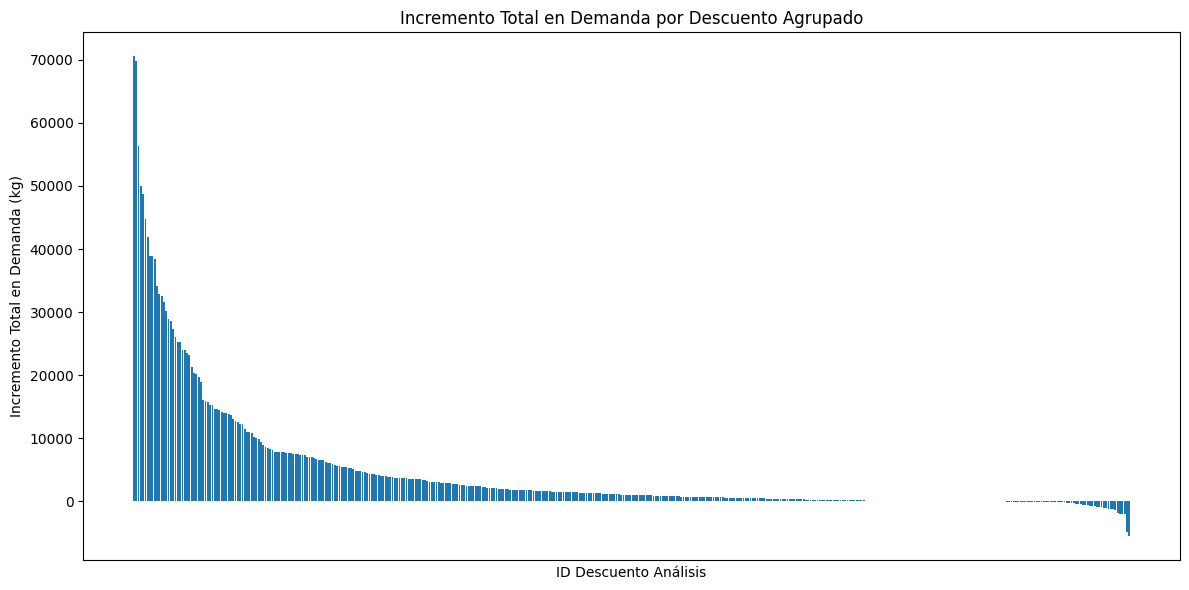

In [85]:
# Graficamos el incremento de demanda de cada descuento agrupado,
# ordenados de mayor a menor en el eje x del gráfico.
data_grafico = resultados_df.sort_values("Incremento Demanda Total (kg)", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
plt.bar(
    data_grafico[ID_COL_ANALISIS],
    data_grafico["Incremento Demanda Total (kg)"],
)
plt.title("Incremento Total en Demanda por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Incremento Total en Demanda (kg)")
plt.xticks([])
plt.tight_layout()
plt.show()


## 5.4 Descuentos ordenados por ROP

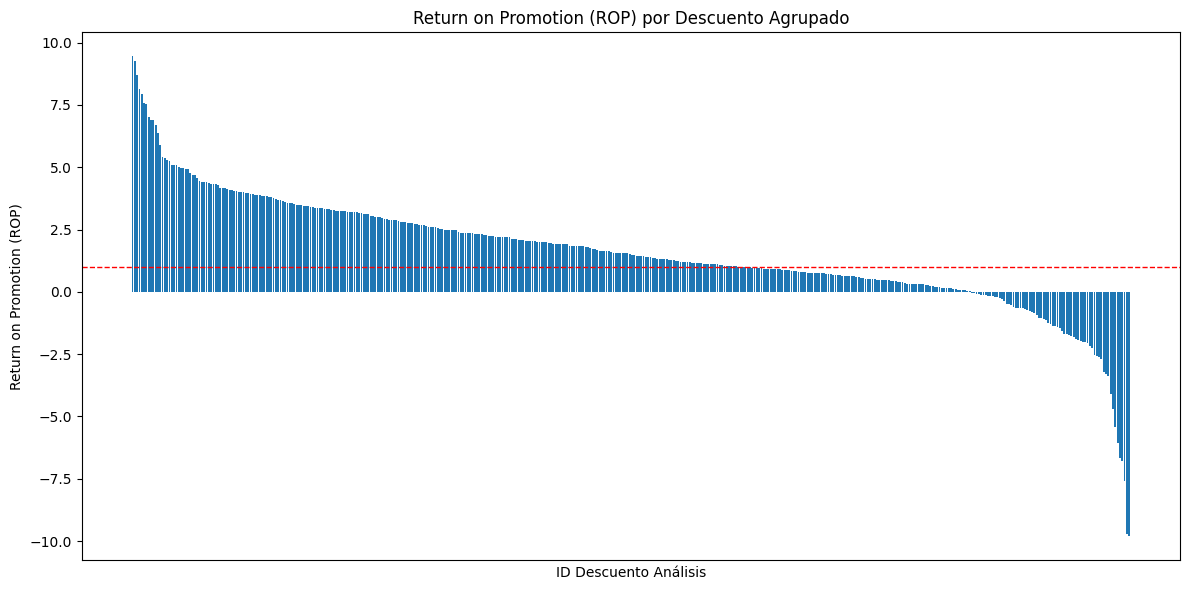

In [86]:
# Graficamos el ROP de cada descuento agrupado, ordenados de mayor a menor
data_grafico = resultados_df.sort_values("ROP", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
plt.bar(
    data_grafico[ID_COL_ANALISIS],
    data_grafico["ROP"],
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.tight_layout()
plt.show()


In [87]:
tol = 1e-4
condiciones = [
    data_grafico["ROP"] < -10,
    (data_grafico["ROP"] >= -10) & (data_grafico["ROP"] < -1),
    (data_grafico["ROP"] >= -1) & (data_grafico["ROP"] < 0),
    data_grafico["ROP"].abs() <= tol,
    (data_grafico["ROP"] > 0) & (data_grafico["ROP"] <= 1),
    data_grafico["ROP"] > 1
]

labels = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "> 1"
]

# crear columna categórica
data_grafico["rango_rop"] = np.select(condiciones, labels, default="otros")

# tabla de conteo
tabla = data_grafico["rango_rop"].value_counts().reindex(labels, fill_value=0).reset_index()
tabla.columns = ["rango_rop", "cantidad"]

display(tabla)

,rango_rop,cantidad
0,< -10,0
1,-10 a -1,40
2,-1 a 0,29
3,≈ 0,0
4,0 a 1,99
5,> 1,264


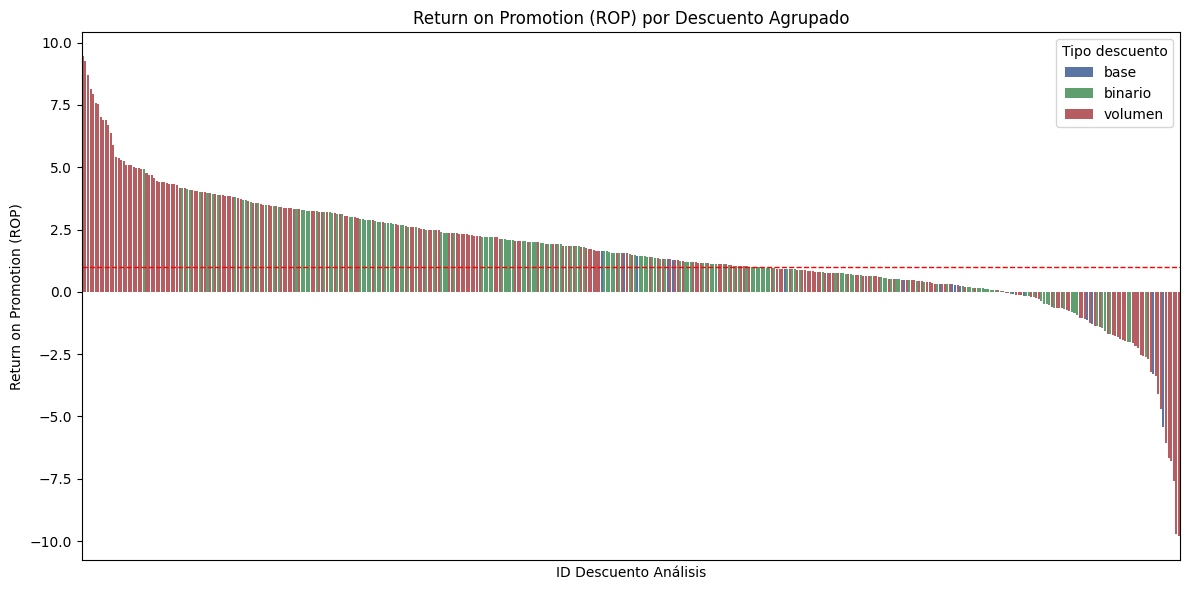

In [88]:
# Gráfico: ROP por descuento agrupado, coloreado por tipo_descuento

data_grafico = resultados_df.sort_values(
    "ROP",
    ascending=False,
).copy()

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()


Descuentos Base Analizados: 17


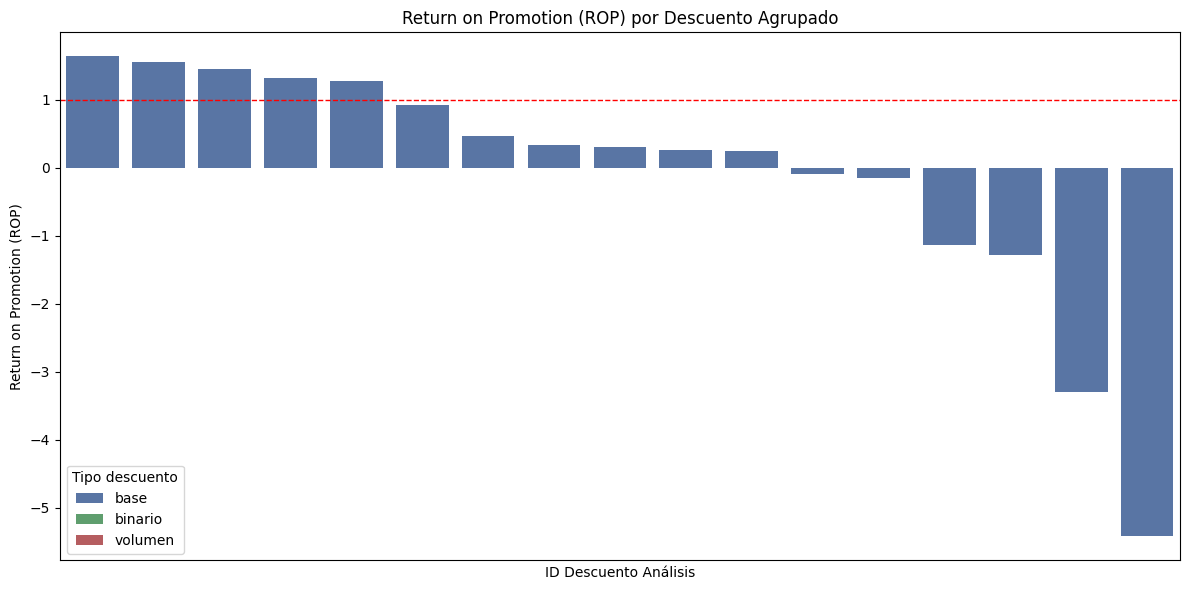

In [89]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "base"
].sort_values(
    "ROP",
    ascending=False,
).copy()

print(f"Descuentos Base Analizados: {data_grafico.shape[0]}")

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

Descuentos Binario Analizados: 173


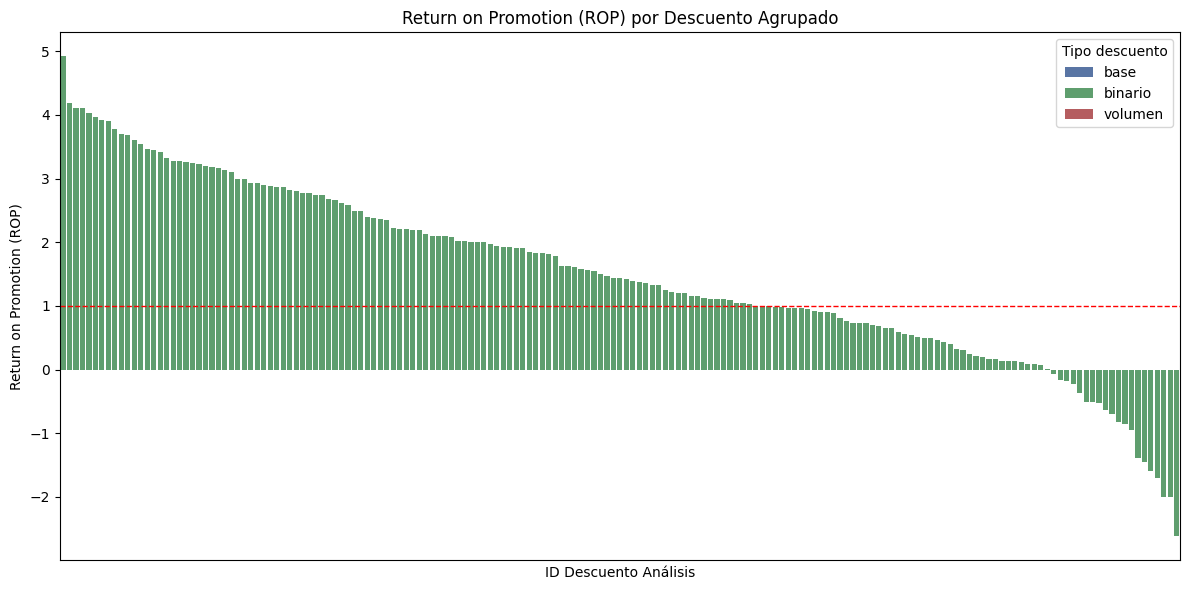

In [90]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "binario"
].sort_values(
    "ROP",
    ascending=False,
).copy()
print(f"Descuentos Binario Analizados: {data_grafico.shape[0]}")

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

Descuentos Volumen Analizados: 242


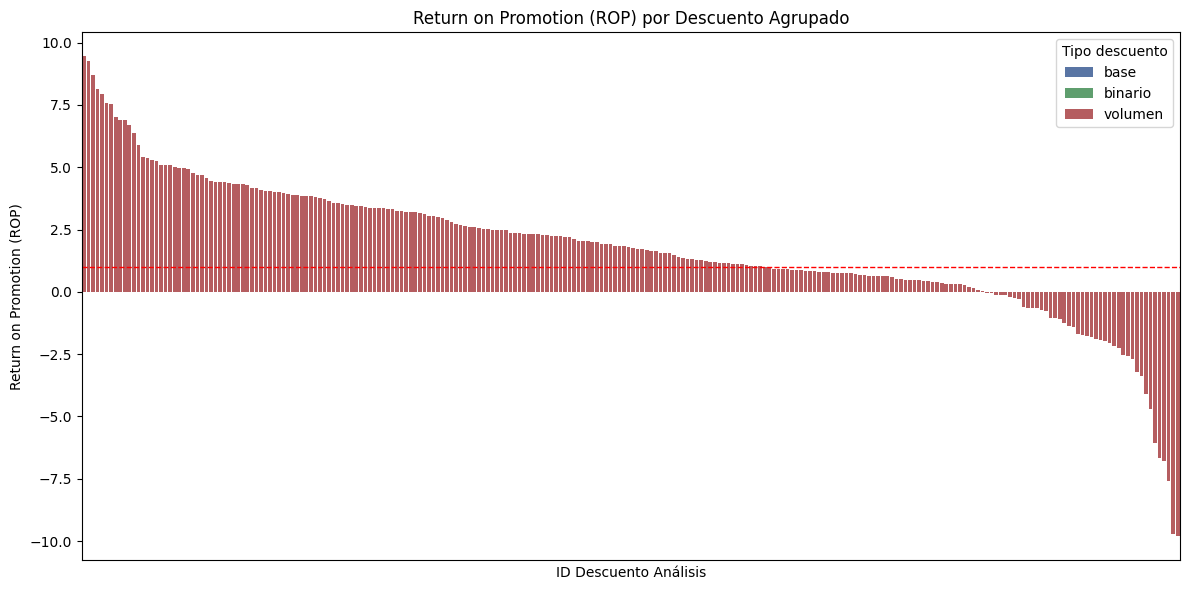

In [91]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "volumen"
].sort_values(
    "ROP",
    ascending=False,
).copy()
print(f"Descuentos Volumen Analizados: {data_grafico.shape[0]}")


data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

In [92]:
# Tabla resumen de rangos ROP por tipo_descuento
data_grafico = resultados_df.sort_values(
    "ROP",
    ascending=False,
).copy()
tol = 1e-4

condiciones = [
    data_grafico["ROP"] < -10,
    (data_grafico["ROP"] >= -10) & (data_grafico["ROP"] < -1),
    (data_grafico["ROP"] >= -1) & (data_grafico["ROP"] < -tol),
    data_grafico["ROP"].abs() <= tol,
    (data_grafico["ROP"] > tol) & (data_grafico["ROP"] <= 1),
    (data_grafico["ROP"] > 1) & (data_grafico["ROP"] <= 2),
    (data_grafico["ROP"] > 2) & (data_grafico["ROP"] <= 5),
    data_grafico["ROP"] > 5,
]

labels = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_grafico["rango_rop"] = np.select(
    condiciones,
    labels,
    default="otros"
)

data_grafico["rango_rop"] = pd.Categorical(
    data_grafico["rango_rop"],
    categories=labels,
    ordered=True
)

tabla = (
    pd.crosstab(
        data_grafico["rango_rop"],
        data_grafico["tipo_descuento"]
    )
    .reindex(labels, fill_value=0)
)

# Asegurar columnas esperadas aunque alguna no aparezca en los datos filtrados
for col in ["base", "binario", "volumen"]:
    if col not in tabla.columns:
        tabla[col] = 0

tabla = tabla[["base", "binario", "volumen"]]
tabla["total"] = tabla.sum(axis=1)

tabla = tabla.reset_index()

# Validaciones solicitadas
# assert tabla["total"].sum() == len(data_grafico), (
#     f"La suma de tabla['total']={tabla['total'].sum()} "
#     f"no coincide con len(data_grafico)={len(data_grafico)}"
# )

assert (
    tabla[["base", "binario", "volumen"]].sum(axis=1) == tabla["total"]
).all(), "Las columnas por tipo no suman correctamente el total por rango."

display(tabla)

tipo_descuento,rango_rop,base,binario,volumen,total
0,< -10,0,0,0,0
1,-10 a -1,4,7,29,40
2,-1 a 0,2,13,14,29
3,≈ 0,0,0,0,0
4,0 a 1,6,45,48,99
5,1 a 2,5,42,38,85
6,2 a 5,0,66,92,158
7,> 5,0,0,21,21


## 5.5 Duración y monto del descuento vs ROP

In [93]:
# ------------------------------------------------------------
# 1. Preparar base de análisis
# ------------------------------------------------------------

data_rop = resultados_df.copy()

# Asegurar tipo_descuento si no quedó en resultados_df
if "tipo_descuento" not in data_rop.columns:
    tipo_por_descuento = (
        descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
        .drop_duplicates(ID_COL_ANALISIS)
    )

    data_rop = data_rop.merge(
        tipo_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

# Asegurar monto_descuento_min/max si no quedaron en resultados_df
cols_monto_descuento = ["monto_descuento_min", "monto_descuento_max"]

if not all(col in data_rop.columns for col in cols_monto_descuento):
    monto_por_descuento = (
        descuentos_analisis[
            [ID_COL_ANALISIS, "monto_descuento_min", "monto_descuento_max"]
        ]
        .drop_duplicates(ID_COL_ANALISIS)
    )

    data_rop = data_rop.merge(
        monto_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

# Monto representativo del descuento.
# Para descuentos de volumen agrupados puede haber varios tramos, por eso usamos el promedio entre min y max.
data_rop["monto_descuento_representativo"] = (
    data_rop[["monto_descuento_min", "monto_descuento_max"]]
    .mean(axis=1)
)

# Filtrar observaciones válidas
data_rop = data_rop[
    data_rop["ROP"].notna()
    & np.isfinite(data_rop["ROP"])
    & data_rop["duracion_dias"].notna()
].copy()

# ------------------------------------------------------------
# 2. Crear rangos de ROP con los mismos intervalos definidos antes
# ------------------------------------------------------------

tol = 1e-4

condiciones = [
    data_rop["ROP"] < -10,
    (data_rop["ROP"] >= -10) & (data_rop["ROP"] < -1),
    (data_rop["ROP"] >= -1) & (data_rop["ROP"] < -tol),
    data_rop["ROP"].abs() <= tol,
    (data_rop["ROP"] > tol) & (data_rop["ROP"] <= 1),
    (data_rop["ROP"] > 1) & (data_rop["ROP"] <= 2),
    (data_rop["ROP"] > 2) & (data_rop["ROP"] <= 5),
    data_rop["ROP"] > 5,
]

labels_rop = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_rop["rango_rop"] = np.select(
    condiciones,
    labels_rop,
    default="otros",
)

data_rop["rango_rop"] = pd.Categorical(
    data_rop["rango_rop"],
    categories=labels_rop,
    ordered=True,
)


def graficar_scatter_categorico_rop(
    data,
    columna_categoria,
    titulo,
    xlabel,
):
    datos = data[
        data["ROP"].notna()
        & np.isfinite(data["ROP"])
        & data[columna_categoria].notna()
    ].copy()

    datos[columna_categoria] = (
        datos[columna_categoria]
        .astype("string")
        .fillna(ETIQUETAS_FALTANTES_CLASIFICACION_SKU[columna_categoria])
        .str.strip()
    )

    orden_categorias = datos[columna_categoria].value_counts().index.tolist()
    orden_tipos_presentes = [
        tipo for tipo in orden_tipos_descuento
        if tipo in datos["tipo_descuento"].dropna().unique()
    ]

    ancho_figura = min(max(12, 0.55 * len(orden_categorias) + 4), 24)

    plt.figure(figsize=(ancho_figura, 6))

    sns.stripplot(
        data=datos,
        x=columna_categoria,
        y="ROP",
        hue="tipo_descuento",
        order=orden_categorias,
        hue_order=orden_tipos_presentes,
        palette=paleta_tipo_descuento,
        dodge=True,
        jitter=0.28,
        alpha=0.6,
        size=5,
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axhline(1, linestyle="--", linewidth=1)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel("Return on Promotion (ROP)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Tipo descuento", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [94]:

# ------------------------------------------------------------
# 3. Tabla: distribución de duración de descuentos por rango de ROP
# ------------------------------------------------------------

tabla_duracion_por_rop = (
    data_rop
    .groupby("rango_rop", observed=False)
    .agg(
        n_descuentos=(ID_COL_ANALISIS, "nunique"),
        duracion_promedio_dias=("duracion_dias", "mean"),
        duracion_mediana_dias=("duracion_dias", "median"),
        duracion_min_dias=("duracion_dias", "min"),
        duracion_p25_dias=("duracion_dias", lambda x: x.quantile(0.25)),
        duracion_p75_dias=("duracion_dias", lambda x: x.quantile(0.75)),
        duracion_max_dias=("duracion_dias", "max"),
        rop_promedio=("ROP", "mean"),
        rop_mediana=("ROP", "median"),
    )
    .reset_index()
)

tabla_duracion_por_rop = tabla_duracion_por_rop.round({
    "duracion_promedio_dias": 1,
    "duracion_mediana_dias": 1,
    "duracion_p25_dias": 1,
    "duracion_p75_dias": 1,
    "rop_promedio": 2,
    "rop_mediana": 2,
})

display(tabla_duracion_por_rop)

,rango_rop,n_descuentos,duracion_promedio_dias,duracion_mediana_dias,duracion_min_dias,duracion_p25_dias,duracion_p75_dias,duracion_max_dias,rop_promedio,rop_mediana
0,< -10,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-10 a -1,40,23.3,27.5,6.0,13.0,34.0,34.0,-3.01,-2.00
2,-1 a 0,29,22.6,27.0,6.0,13.0,34.0,34.0,-0.42,-0.36
3,≈ 0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0 a 1,99,23.1,27.0,6.0,14.5,30.0,34.0,0.57,0.60
5,1 a 2,85,24.3,27.0,6.0,17.0,34.0,34.0,1.45,1.42
6,2 a 5,158,24.8,27.0,6.0,16.0,30.0,34.0,3.16,3.14
7,> 5,21,24.7,30.0,6.0,16.0,30.0,34.0,6.66,6.67


In [95]:

# ------------------------------------------------------------
# 4. Paleta para pintar por tipo de descuento
# ------------------------------------------------------------

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(data_rop["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]


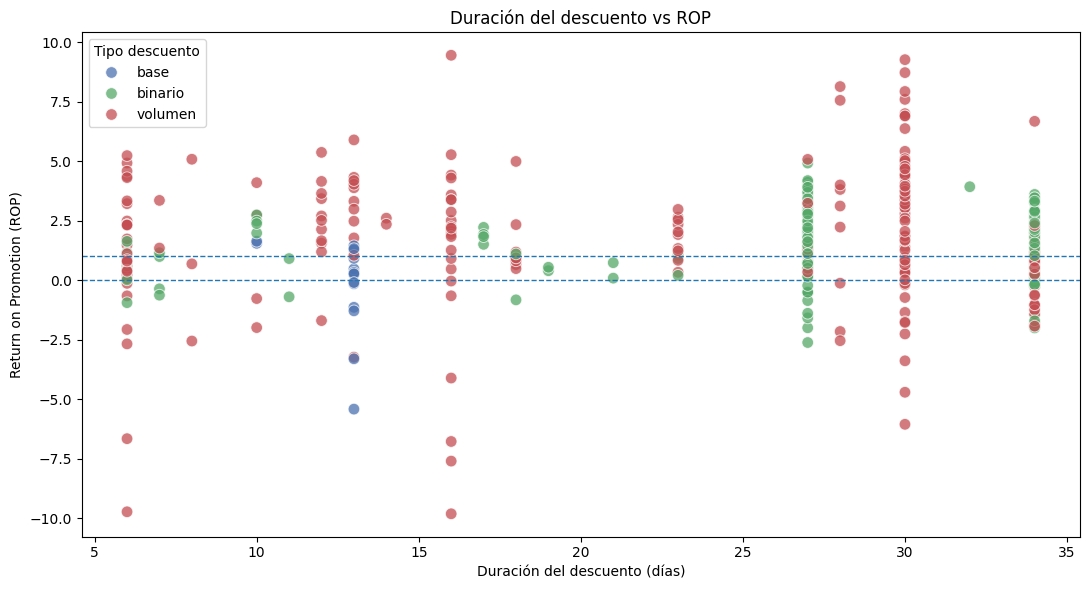

In [96]:
# ------------------------------------------------------------
# 5. Scatterplot: duración del descuento vs ROP
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_rop,
    x="duracion_dias",
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Duración del descuento vs ROP")
plt.xlabel("Duración del descuento (días)")
plt.ylabel("Return on Promotion (ROP)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

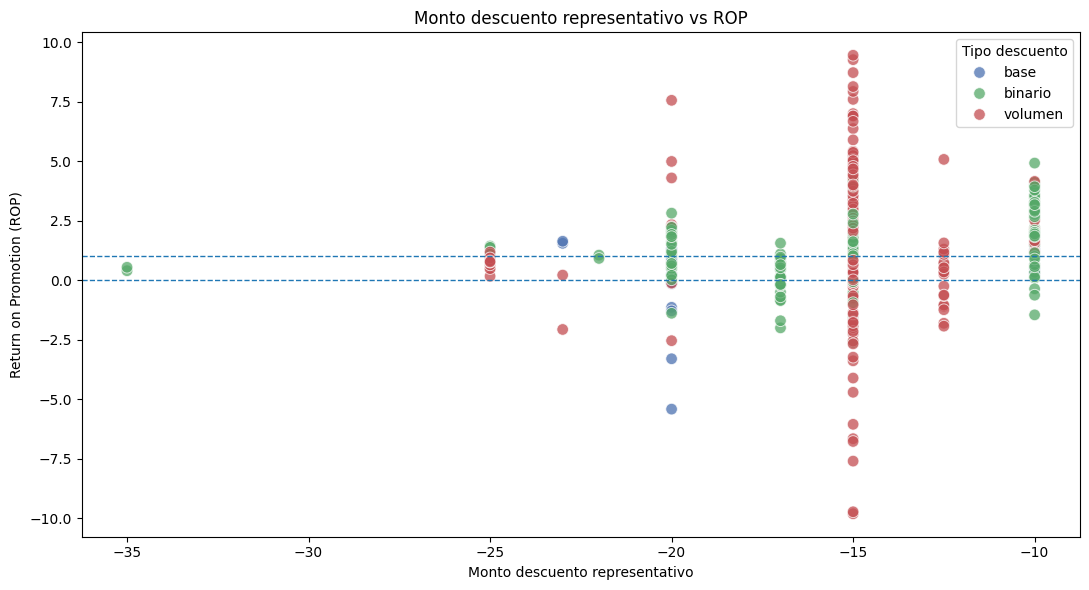

In [97]:
# ------------------------------------------------------------
# 6. Scatterplot: monto descuento representativo vs ROP
# ------------------------------------------------------------

data_monto = data_rop[
    data_rop["monto_descuento_representativo"].notna()
].copy()

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_monto,
    x="monto_descuento_representativo",
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Monto descuento representativo vs ROP")
plt.xlabel("Monto descuento representativo")
plt.ylabel("Return on Promotion (ROP)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

## 5.6 Scatterplots categóricos de ROP por clasificación SKU

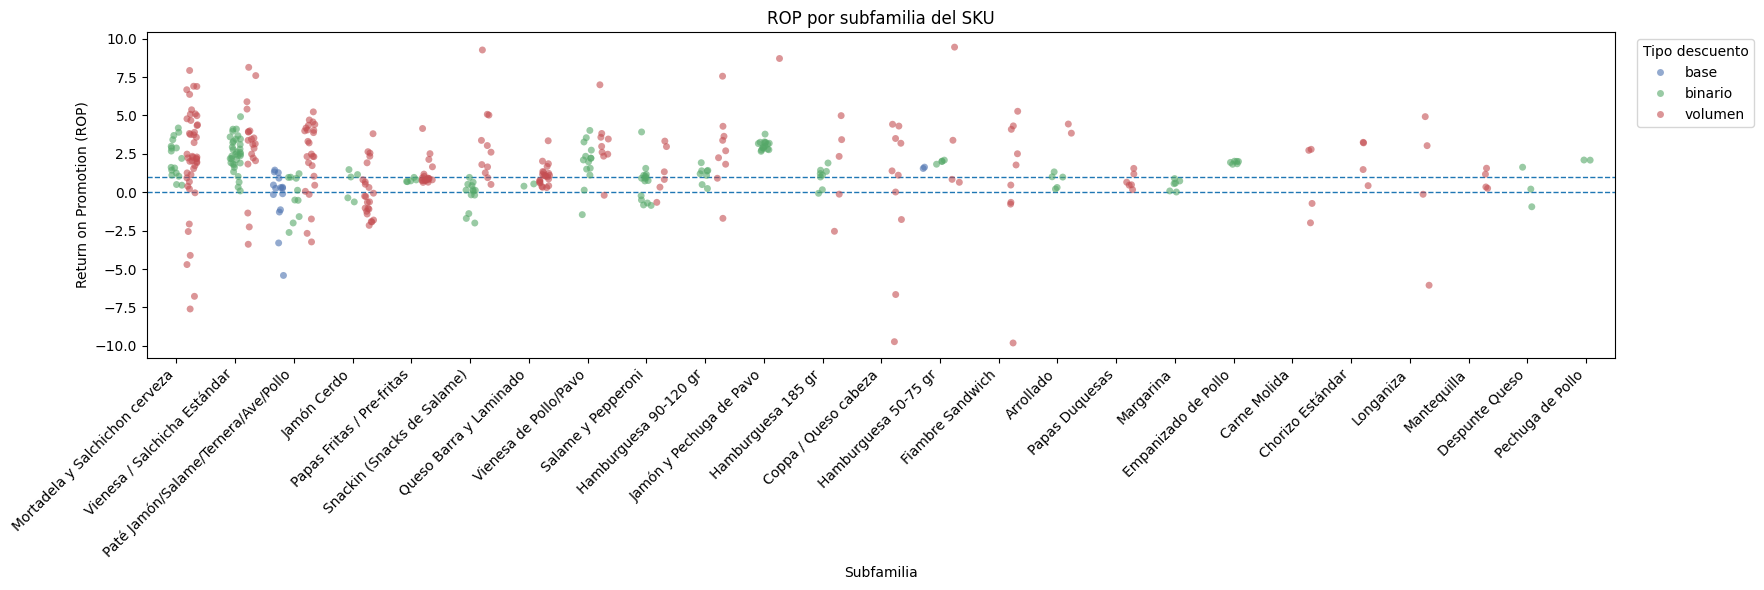

In [98]:
graficar_scatter_categorico_rop(
    data_rop,
    "subfamilia",
    titulo="ROP por subfamilia del SKU",
    xlabel="Subfamilia",
)

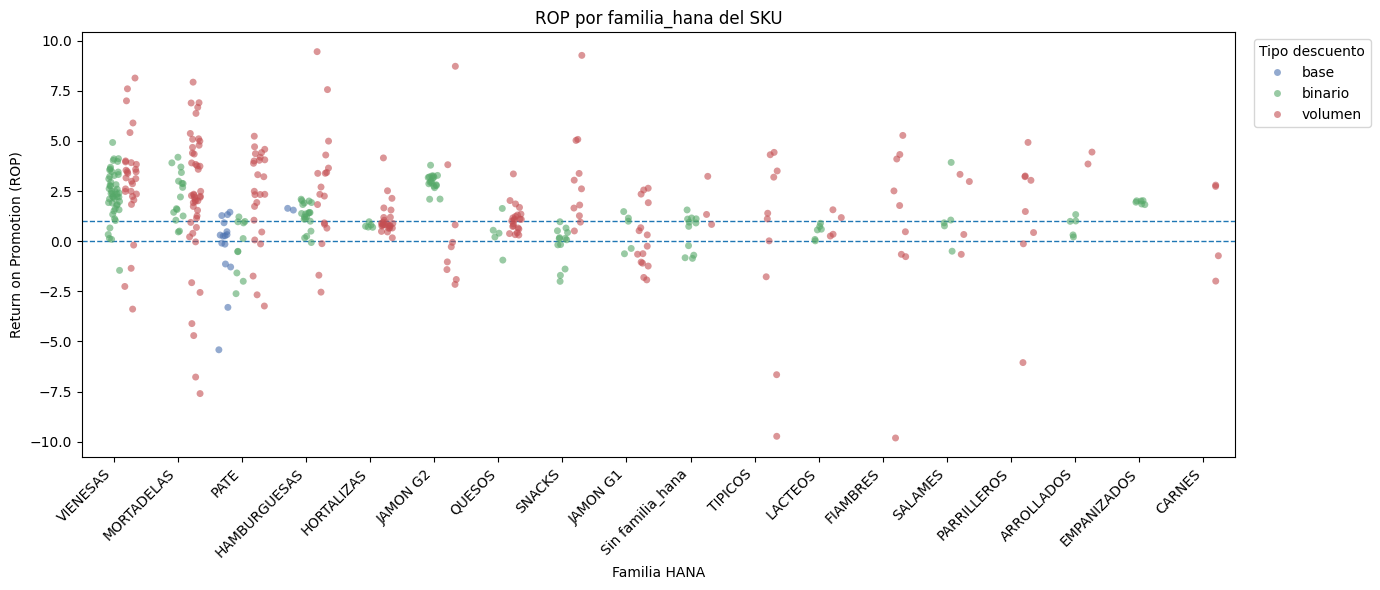

In [99]:
graficar_scatter_categorico_rop(
    data_rop,
    "familia_hana",
    titulo="ROP por familia_hana del SKU",
    xlabel="Familia HANA",
)

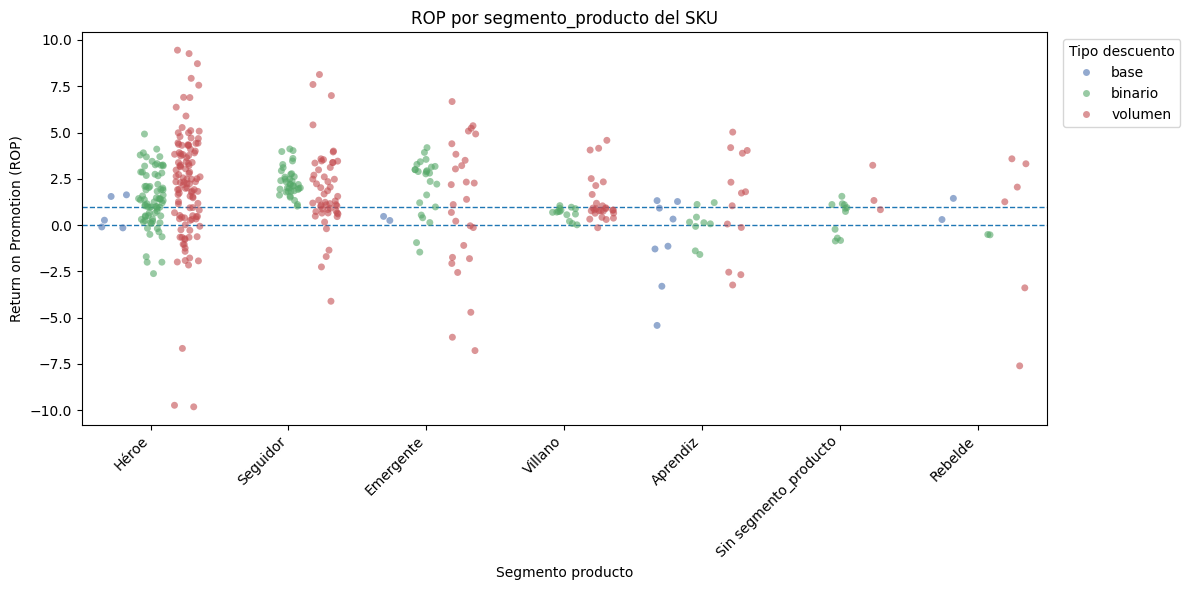

In [100]:
graficar_scatter_categorico_rop(
    data_rop,
    "segmento_producto",
    titulo="ROP por segmento_producto del SKU",
    xlabel="Segmento producto",
)

## 5.7 Duración del baseline utilizado vs ROP

,rango_rop,n_descuentos,dias_baseline_promedio,dias_baseline_mediana,dias_baseline_min,dias_baseline_p25,dias_baseline_p75,dias_baseline_max,span_calendario_mediana,pct_con_fallback_precio_maximo,rop_mediana
0,< -10,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-10 a -1,40,57.6,69.5,15.0,41.0,76.0,76.0,89.0,0.0,-2.00
2,-1 a 0,29,45.2,45.0,12.0,27.0,63.0,76.0,58.0,0.0,-0.36
3,≈ 0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0 a 1,99,50.7,53.0,12.0,29.0,73.5,76.0,78.0,0.0,0.60
5,1 a 2,85,51.5,64.0,12.0,28.0,76.0,76.0,86.0,0.0,1.42
6,2 a 5,158,49.6,47.0,12.0,29.0,75.0,76.0,77.0,0.0,3.14
7,> 5,21,64.8,76.0,12.0,68.0,76.0,76.0,89.0,0.0,6.67


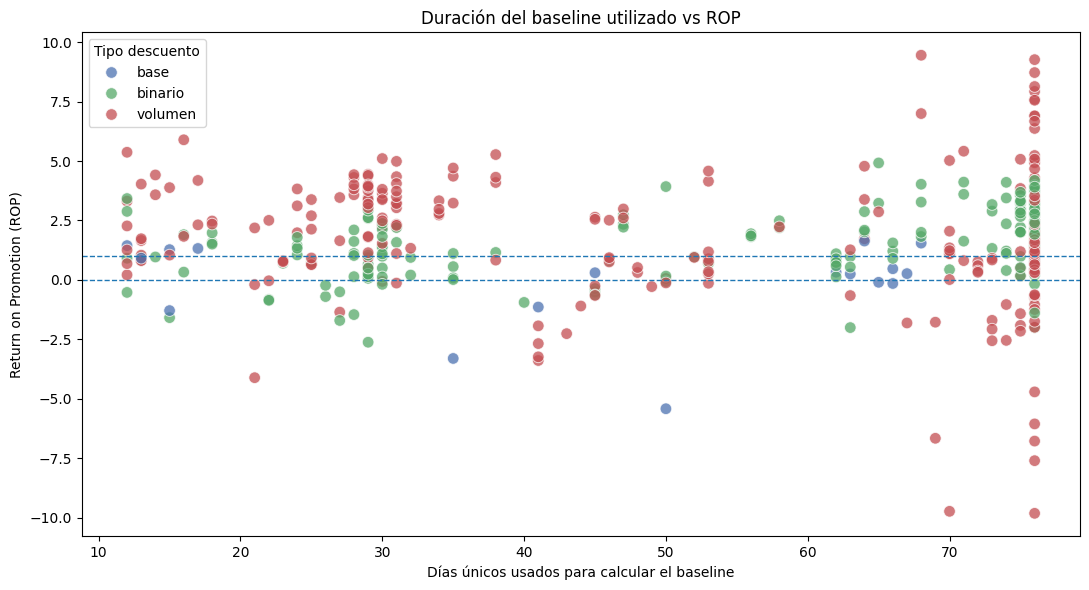

In [101]:
# ============================================================
# Duración del baseline utilizado vs ROP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columnas_baseline_requeridas = [
    "dias_baseline_usados",
    "fecha_min_baseline",
    "fecha_max_baseline",
    "span_calendario_baseline_dias",
    "n_transacciones_baseline",
    "kg_baseline",
    "uso_fallback_precio_maximo",
]

columnas_baseline_faltantes = [
    columna
    for columna in columnas_baseline_requeridas
    if columna not in resultados_df.columns
]

if columnas_baseline_faltantes:
    raise KeyError(
        "Falta metadata de baseline centralizada en resultados_df: "
        + ", ".join(columnas_baseline_faltantes)
    )

data_baseline_rop = resultados_df.copy()
data_baseline_rop["ROP"] = pd.to_numeric(data_baseline_rop["ROP"], errors="coerce")
data_baseline_rop["dias_baseline_usados"] = pd.to_numeric(
    data_baseline_rop["dias_baseline_usados"],
    errors="coerce",
)
data_baseline_rop["span_calendario_baseline_dias"] = pd.to_numeric(
    data_baseline_rop["span_calendario_baseline_dias"],
    errors="coerce",
)
data_baseline_rop["uso_fallback_precio_maximo"] = (
    data_baseline_rop["uso_fallback_precio_maximo"]
    .replace({"True": True, "False": False, "true": True, "false": False})
    .fillna(False)
    .astype(bool)
)

data_baseline_rop = data_baseline_rop[
    data_baseline_rop["ROP"].notna()
    & np.isfinite(data_baseline_rop["ROP"])
    & data_baseline_rop["dias_baseline_usados"].notna()
    & (data_baseline_rop["dias_baseline_usados"] > 0)
].copy()

# ------------------------------------------------------------
# 1. Crear rangos de ROP
# ------------------------------------------------------------

tol = 1e-4

condiciones = [
    data_baseline_rop["ROP"] < -10,
    (data_baseline_rop["ROP"] >= -10) & (data_baseline_rop["ROP"] < -1),
    (data_baseline_rop["ROP"] >= -1) & (data_baseline_rop["ROP"] < -tol),
    data_baseline_rop["ROP"].abs() <= tol,
    (data_baseline_rop["ROP"] > tol) & (data_baseline_rop["ROP"] <= 1),
    (data_baseline_rop["ROP"] > 1) & (data_baseline_rop["ROP"] <= 2),
    (data_baseline_rop["ROP"] > 2) & (data_baseline_rop["ROP"] <= 5),
    data_baseline_rop["ROP"] > 5,
]

labels_rop = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_baseline_rop["rango_rop"] = np.select(
    condiciones,
    labels_rop,
    default="otros",
)

data_baseline_rop["rango_rop"] = pd.Categorical(
    data_baseline_rop["rango_rop"],
    categories=labels_rop,
    ordered=True,
)

# ------------------------------------------------------------
# 2. Tabla: duración del baseline por rango de ROP
# ------------------------------------------------------------

tabla_baseline_por_rop = (
    data_baseline_rop
    .groupby("rango_rop", observed=False)
    .agg(
        n_descuentos=(ID_COL_ANALISIS, "nunique"),
        dias_baseline_promedio=("dias_baseline_usados", "mean"),
        dias_baseline_mediana=("dias_baseline_usados", "median"),
        dias_baseline_min=("dias_baseline_usados", "min"),
        dias_baseline_p25=("dias_baseline_usados", lambda x: x.quantile(0.25)),
        dias_baseline_p75=("dias_baseline_usados", lambda x: x.quantile(0.75)),
        dias_baseline_max=("dias_baseline_usados", "max"),
        span_calendario_mediana=("span_calendario_baseline_dias", "median"),
        pct_con_fallback_precio_maximo=("uso_fallback_precio_maximo", "mean"),
        rop_mediana=("ROP", "median"),
    )
    .reset_index()
)

tabla_baseline_por_rop["pct_con_fallback_precio_maximo"] = (
    tabla_baseline_por_rop["pct_con_fallback_precio_maximo"] * 100
)

tabla_baseline_por_rop = tabla_baseline_por_rop.round({
    "dias_baseline_promedio": 1,
    "dias_baseline_mediana": 1,
    "dias_baseline_p25": 1,
    "dias_baseline_p75": 1,
    "span_calendario_mediana": 1,
    "pct_con_fallback_precio_maximo": 1,
    "rop_mediana": 2,
})

display(tabla_baseline_por_rop)

# ------------------------------------------------------------
# 3. Scatterplot: duración del baseline vs ROP, pintado por tipo de descuento
# ------------------------------------------------------------

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(data_baseline_rop["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_baseline_rop,
    x="dias_baseline_usados",
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Duración del baseline utilizado vs ROP")
plt.xlabel("Días únicos usados para calcular el baseline")
plt.ylabel("Return on Promotion (ROP)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

## 5.8 ROP vs uplift de volumen


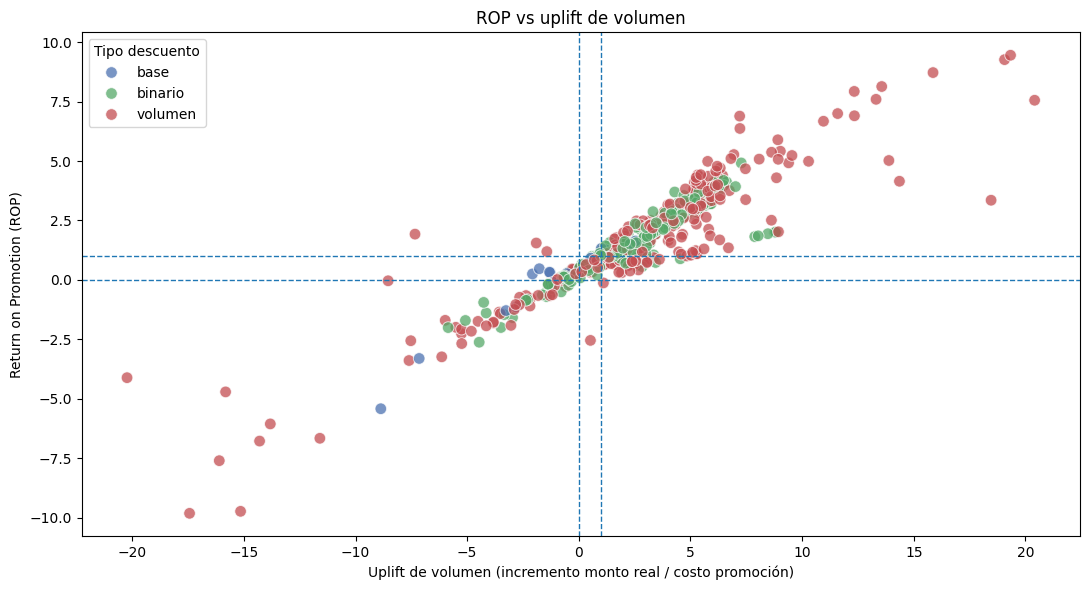

In [102]:
# ============================================================
# ROP vs uplift de volumen
# ============================================================

data_uplift_rop = resultados_df[
    resultados_df["ROP"].notna()
    & np.isfinite(resultados_df["ROP"])
    & resultados_df["Uplift de volumen"].notna()
    & np.isfinite(resultados_df["Uplift de volumen"])
].copy()

if "tipo_descuento" not in data_uplift_rop.columns:
    tipo_por_descuento = (
        descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
        .drop_duplicates(ID_COL_ANALISIS)
    )
    data_uplift_rop = data_uplift_rop.merge(
        tipo_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

if "paleta_tipo_descuento" not in globals() or "orden_tipos_descuento" not in globals():
    paleta_tipo_descuento = {
        "base": "#4C72B0",
        "binario": "#55A868",
        "volumen": "#C44E52",
    }

    tipos_presentes = sorted(data_uplift_rop["tipo_descuento"].dropna().unique())
    tipos_inesperados = [
        tipo for tipo in tipos_presentes
        if tipo not in paleta_tipo_descuento
    ]

    if tipos_inesperados:
        colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
        paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

    orden_tipos_descuento = [
        tipo for tipo in ["base", "binario", "volumen"]
        if tipo in tipos_presentes
    ] + [
        tipo for tipo in tipos_presentes
        if tipo not in ["base", "binario", "volumen"]
    ]

if data_uplift_rop.empty:
    print("No hay descuentos con ROP y Uplift de volumen válidos para graficar.")
else:
    plt.figure(figsize=(11, 6))

    sns.scatterplot(
        data=data_uplift_rop,
        x="Uplift de volumen",
        y="ROP",
        hue="tipo_descuento",
        hue_order=orden_tipos_descuento,
        palette=paleta_tipo_descuento,
        alpha=0.75,
        s=70,
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axhline(1, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.axvline(1, linestyle="--", linewidth=1)

    plt.title("ROP vs uplift de volumen")
    plt.xlabel("Uplift de volumen (incremento monto real / costo promoción)")
    plt.ylabel("Return on Promotion (ROP)")
    plt.legend(title="Tipo descuento")
    plt.tight_layout()
    plt.show()
